In [ ]:
import os
from scipy.ndimage import uniform_filter1d
from sklearn.metrics import roc_auc_score, average_precision_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from chronos import BaseChronosPipeline, Chronos2Pipeline

# Load the Chronos-2 pipeline
# GPU recommended for faster inference, but CPU is also supported using device_map="cpu"
# Use only 1 GPU if available
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

pipeline: Chronos2Pipeline = BaseChronosPipeline.from_pretrained("amazon/chronos-2", device_map="cuda")

/home/rajib/miniconda3/envs/chronos_clean/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_original = pd.read_csv('/home/rajib/mTSBench/Datasets/mTSBench/SMD/SMD_machine-1-4_test.csv')
# df_original = pd.read_csv('/home/rajib/mTSBench/Datasets/mTSBench/Exathlon/Exathlon_1_4_1000000_80_test.csv')

### Helper function for prediction

In [ ]:

def compute_feature_score(y_actual, group_df, method="mse"):
    
    y_median = group_df["0.5"].values
    y_lower  = group_df["0.1"].values
    y_upper  = group_df["0.9"].values

    if method == "mse":
        return (y_actual - y_median) ** 2
    
    elif method == "smape":
        y_pred = group_df["0.5"].values  # median prediction

        eps = 1e-8
        numerator   = np.abs(y_actual - y_pred)
        denominator = np.abs(y_actual) + np.abs(y_pred) + eps
        return 2*(numerator / denominator)

    elif method == "interval":
        upper_violation = np.maximum(0.0, y_actual - y_upper)
        lower_violation = np.maximum(0.0, y_lower  - y_actual)
        return upper_violation + lower_violation

    else:  
        band_width = y_upper - y_lower + 1e-8
        deviation  = np.abs(y_actual - y_median)
        return deviation / band_width


def aggregate_scores(anomaly_df, method="l2"):

    if method == "l2":
        return np.sqrt((anomaly_df ** 2).sum(axis=1))

    elif method == "max":
        return anomaly_df.max(axis=1).values

    elif method == "mean":
        return anomaly_df.mean(axis=1).values

    else:  # topk_mean (default)
        k = max(1, anomaly_df.shape[1] // 4)
        return anomaly_df.apply(
            lambda row: row.nlargest(k).mean(), axis=1
        ).values


def robust_normalize(series):
    p1  = np.percentile(series, 1)
    p99 = np.percentile(series, 99)
    clipped = np.clip(series, p1, p99)
    denom = p99 - p1
    if denom < 1e-8:
        return np.zeros_like(series, dtype=float)
    return (clipped - p1) / denom

def split_dataset(df, split_ratio):
    split_idx = int(len(df) * split_ratio)
    df_train = df.iloc[:split_idx].reset_index(drop=True)
    df_test = df.iloc[split_idx:].reset_index(drop=True)
    return df_train, df_test

def prepare_df_train(df):
    df = df.copy()
    df["timestamp"] = pd.date_range(
        start="2000-01-01",
        periods=len(df),
        freq="1s"
    )

    df = df.sort_values("timestamp")

    ts = df["timestamp"]
    assert ts.is_monotonic_increasing, "Timestamp column is not sorted"
    assert ts.diff().dropna().nunique() == 1, "Timestamp spacing is not uniform"

    return df


def prepare_df_test(df):
    df = df.copy()
    df["timestamp"] = pd.date_range(
        start="2000-02-01",
        periods=len(df),
        freq="1s"
    )

    df = df.sort_values("timestamp")

    ts = df["timestamp"]
    assert ts.is_monotonic_increasing, "Timestamp column is not sorted"
    assert ts.diff().dropna().nunique() == 1, "Timestamp spacing is not uniform"

    return df


def generate_prediction(df_train, df_test, feature_list, prediction_length, context_length):
    window_length   = prediction_length
    all_predictions = []
    id_column       = "id"
    timestamp_column = "timestamp"
    num_windows     = len(df_test) // window_length
    remainder       = len(df_test) % window_length

    for i in range(num_windows):
        start = i * window_length

        if i == 0:
            df_train_window = df_train.copy()
        else:
            df_past_test    = df_test.iloc[:start].copy()
            df_train_window = pd.concat([df_train, df_past_test], ignore_index=True)

        pred_df = pipeline.predict_df(
            df_train_window,
            future_df=None,
            prediction_length=window_length,
            quantile_levels=[0.1, 0.5, 0.9],
            id_column=id_column,
            timestamp_column=timestamp_column,
            target=feature_list,
            context_length=context_length,
            validate_inputs=False
        )

        pred_df["window_id"] = i
        all_predictions.append(pred_df)

    # -------- Handle remainder window --------
    if remainder > 0:
        start           = num_windows * window_length
        df_past_test    = df_test.iloc[:start].copy()
        df_train_window = pd.concat([df_train, df_past_test], ignore_index=True)

        pred_df = pipeline.predict_df(
            df_train_window,
            future_df=None,
            prediction_length=remainder,
            quantile_levels=[0.1, 0.5, 0.9],
            id_column=id_column,
            timestamp_column=timestamp_column,
            target=feature_list,
            context_length=context_length,
            validate_inputs=False
        )

        pred_df["window_id"] = num_windows
        all_predictions.append(pred_df)

    final_predictions = pd.concat(all_predictions, ignore_index=True)
    return final_predictions

### Prediction

In [ ]:
df_original = prepare_df_test(df_original)
df_train, df_test = split_dataset(df_original, split_ratio=0.2)

df_train["id"] = "Exathlon"
df_test["id"]  = "Exathlon"
feature_list = [
        c for c in df_original.columns
        if c not in ["timestamp", "is_anomaly"]
    ]

prediction_df = generate_prediction(
        df_train, df_test, feature_list, prediction_length=100, context_length=1024
    )

feature_groups = {
    feature: group.reset_index(drop=True) 
    for feature, group in prediction_df.groupby("target_name")
}
grouped = prediction_df.groupby("target_name")

### Prepare Score Funtion

In [ ]:

anomaly_scores = {}

for feature_name, group_df in prediction_df.groupby("target_name"):
    group_df = group_df.reset_index(drop=True)
    y_actual = df_test[feature_name].values

    score = compute_feature_score(y_actual, group_df, method='interval')
    anomaly_scores[feature_name] = score


anomaly_df = pd.DataFrame(anomaly_scores)

anomaly_df = anomaly_df.apply(
    lambda col: pd.Series(robust_normalize(col.values)), axis=0
)
anomaly_df = anomaly_df.fillna(0)

y_score = aggregate_scores(anomaly_df, method='l2')
y_true = df_test["is_anomaly"].values


AUROC: 0.7376 | AUPRC: 0.2726


### Picking top3 features

In [119]:
results = {}

for f in feature_list:
    auprc = average_precision_score(y_true, anomaly_df[f].values)
    results[f] = auprc
top_features = sorted(results, key=results.get, reverse=True)
print(top_features[:3])


['feature_30', 'feature_3', 'feature_34']


### Generate Plots

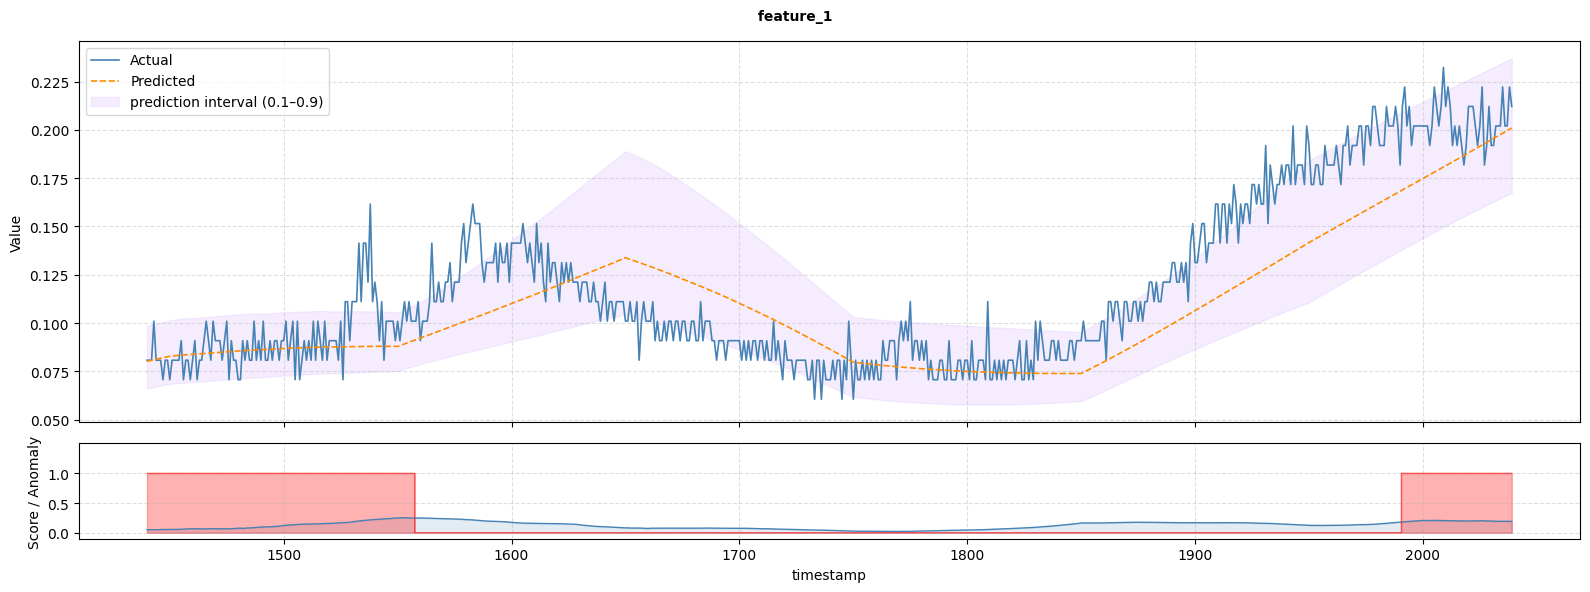

In [ ]:
def plot_forecast_with_anomaly(feature_groups, df_test, y_score, feature_idx=1, plot_from=None, plot_until=None, smooth_window=100):

    feature_list = [col for col in df_test.columns if col != 'is_anomaly']
    feature_col  = feature_list[feature_idx]

    feat_df    = feature_groups[feature_col]
    predicted  = feat_df['0.5'].values
    actual     = df_test[feature_col].values[-len(predicted):]
    is_anomaly = df_test['is_anomaly'].values[-len(predicted):]
    q_low      = feat_df['0.1'].values
    q_high     = feat_df['0.9'].values
    time       = np.arange(len(predicted))

    y_score_scaled = (y_score - y_score.min()) / (y_score.max() - y_score.min())
    y_score_scaled = y_score_scaled.values[-len(predicted):]  

    start = plot_from  if plot_from  is not None else 0
    end   = plot_until if plot_until is not None else len(predicted)

    if smooth_window > 1:
        predicted      = pd.Series(predicted).rolling(smooth_window, center=True, min_periods=1).mean().values
        q_low          = pd.Series(q_low).rolling(smooth_window, center=True, min_periods=1).mean().values
        q_high         = pd.Series(q_high).rolling(smooth_window, center=True, min_periods=1).mean().values
        y_score_scaled = pd.Series(y_score_scaled).rolling(smooth_window, center=True, min_periods=1).mean().values

    predicted      = predicted[start:end]
    actual         = actual[start:end]
    is_anomaly     = is_anomaly[start:end]
    q_low          = q_low[start:end]
    q_high         = q_high[start:end]
    y_score_scaled = y_score_scaled[start:end]
    time           = time[start:end]

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(16, 6),
        sharex=True,
        gridspec_kw={"height_ratios": [4, 1]}
    )
    # fig.suptitle(f' {feature_col} [{start} : {end}]', fontsize=14, fontweight='bold')
    fig.suptitle(f' {feature_col} ', fontsize=10, fontweight='bold')

    ax1.plot(time, actual,    label='Actual',    color='steelblue',  linewidth=1.2)
    ax1.plot(time, predicted, label='Predicted', color='darkorange', linewidth=1.2, linestyle='--')
    ax1.fill_between(time, q_low, q_high, alpha=0.3, color='xkcd:light lavender', label='prediction interval (0.1–0.9)')
    ax1.set_ylabel('Value')
    ax1.legend(loc='upper left')
    ax1.grid(True, linestyle='--', alpha=0.4)

    ax2.plot(time, y_score_scaled, color='steelblue', linewidth=1.0, label='anomaly score')
    ax2.fill_between(time, y_score_scaled, alpha=0.15, color='steelblue')
    ax2.fill_between(time, is_anomaly, step='mid', color='red', alpha=0.3, label='is_anomaly (ground truth)')
    ax2.plot(time, is_anomaly, color='red', linewidth=0.8, drawstyle='steps-mid', alpha=0.6)
    ax2.set_ylabel('Score / Anomaly')
    ax2.set_ylim(-0.1, 1.5)
    ax2.set_yticks([0, 0.5, 1])
    ax2.set_xlabel('timestamp')
    # ax2.legend(loc='upper left')
    ax2.grid(True, linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()



plot_forecast_with_anomaly(feature_groups, df_test, y_score, feature_idx=1, plot_from=1440, plot_until=2040)

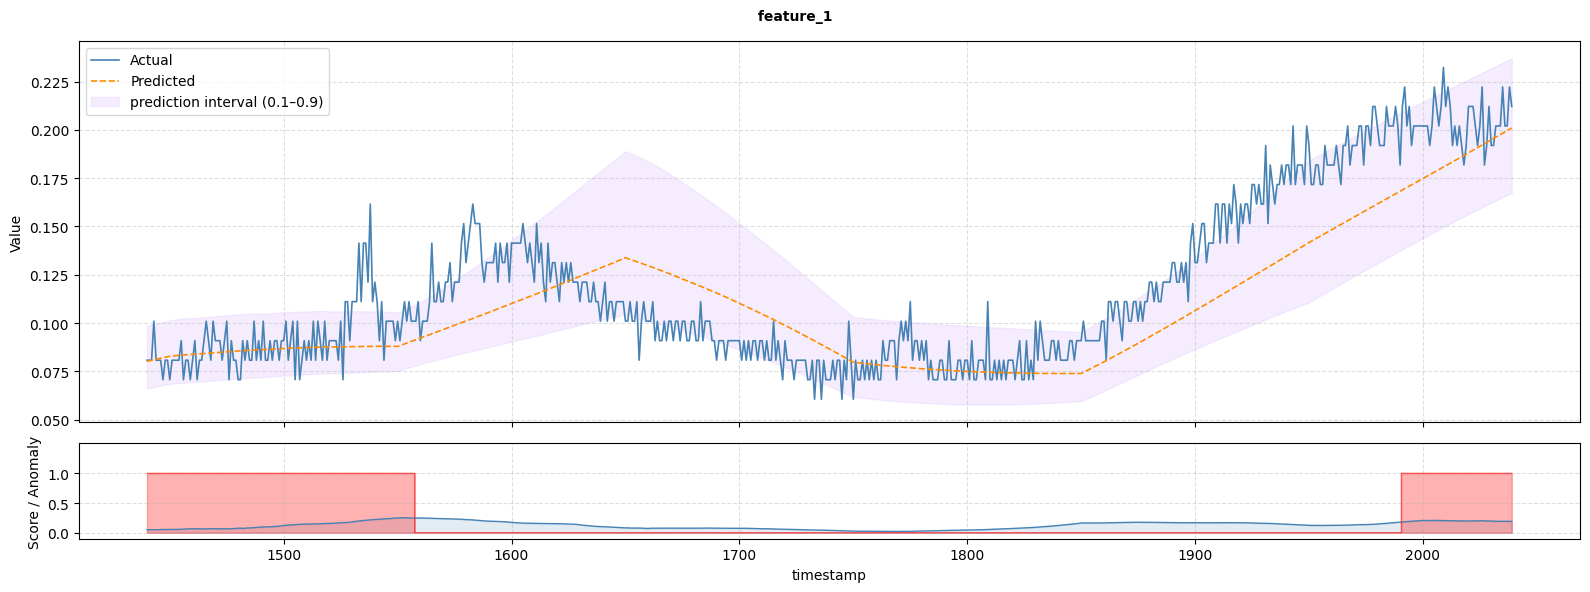

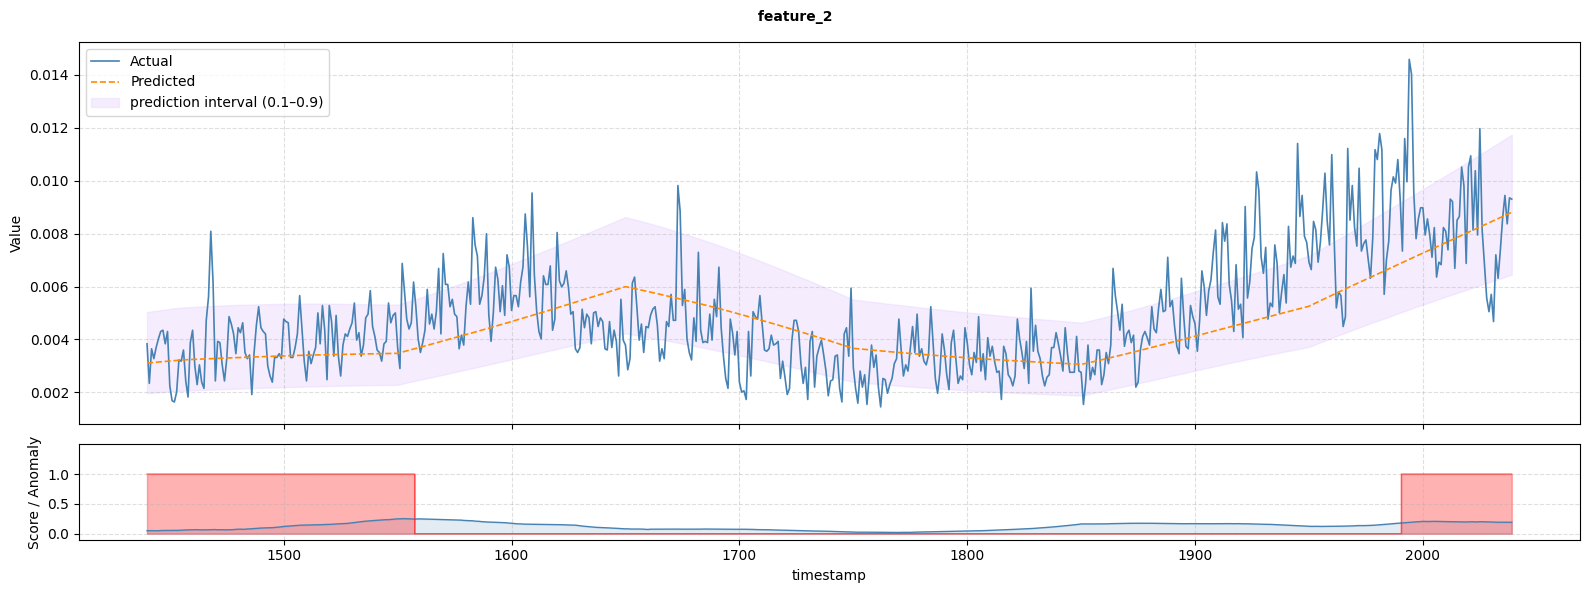

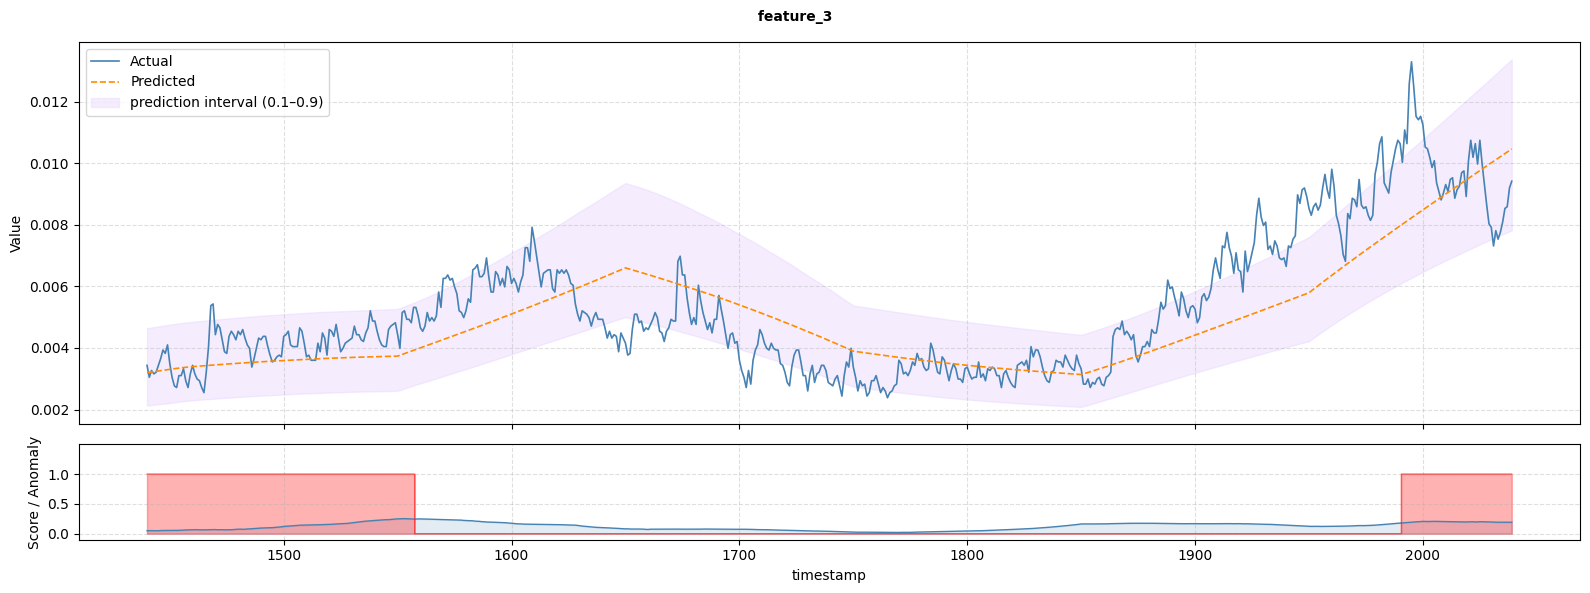

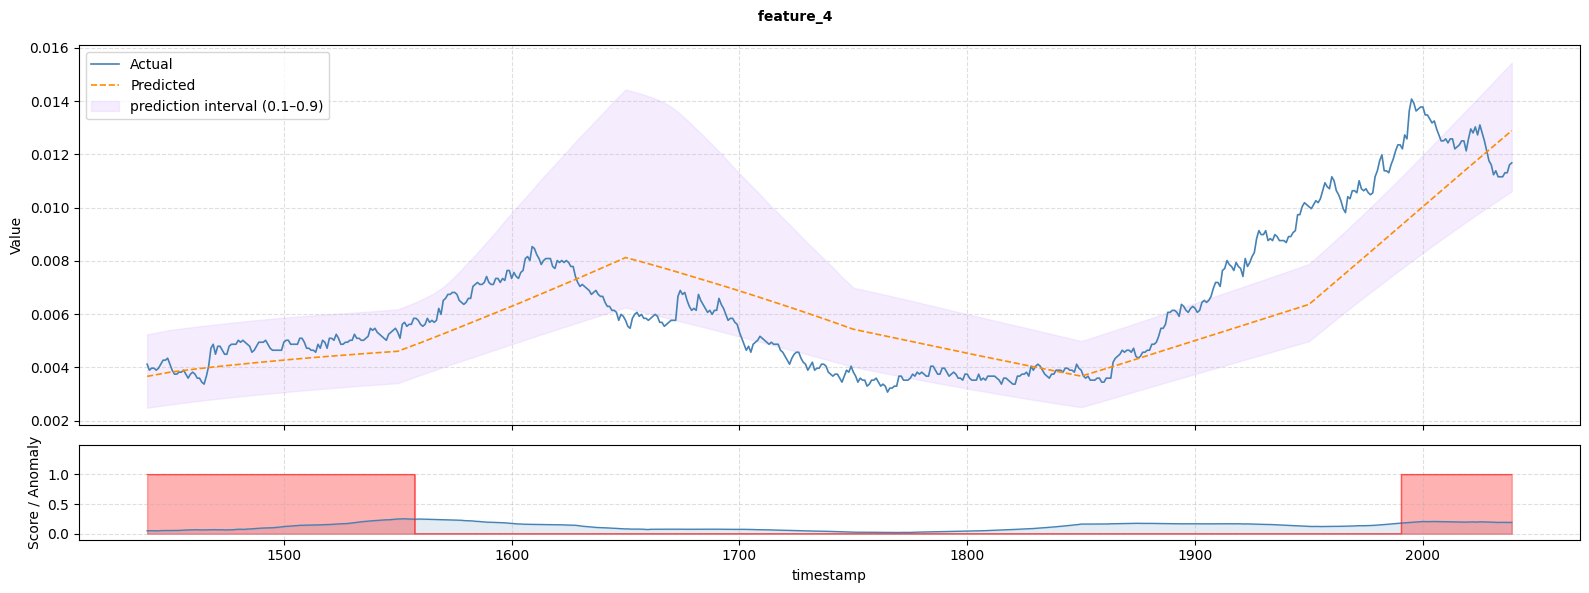

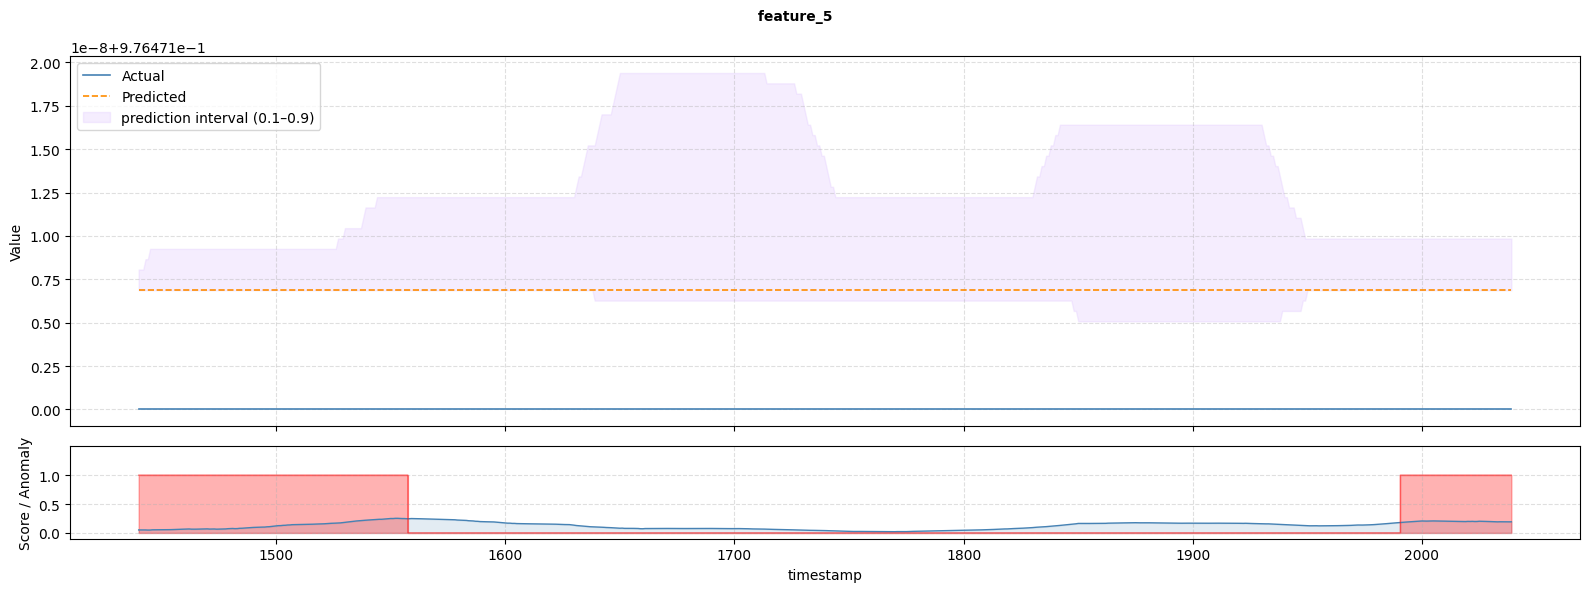

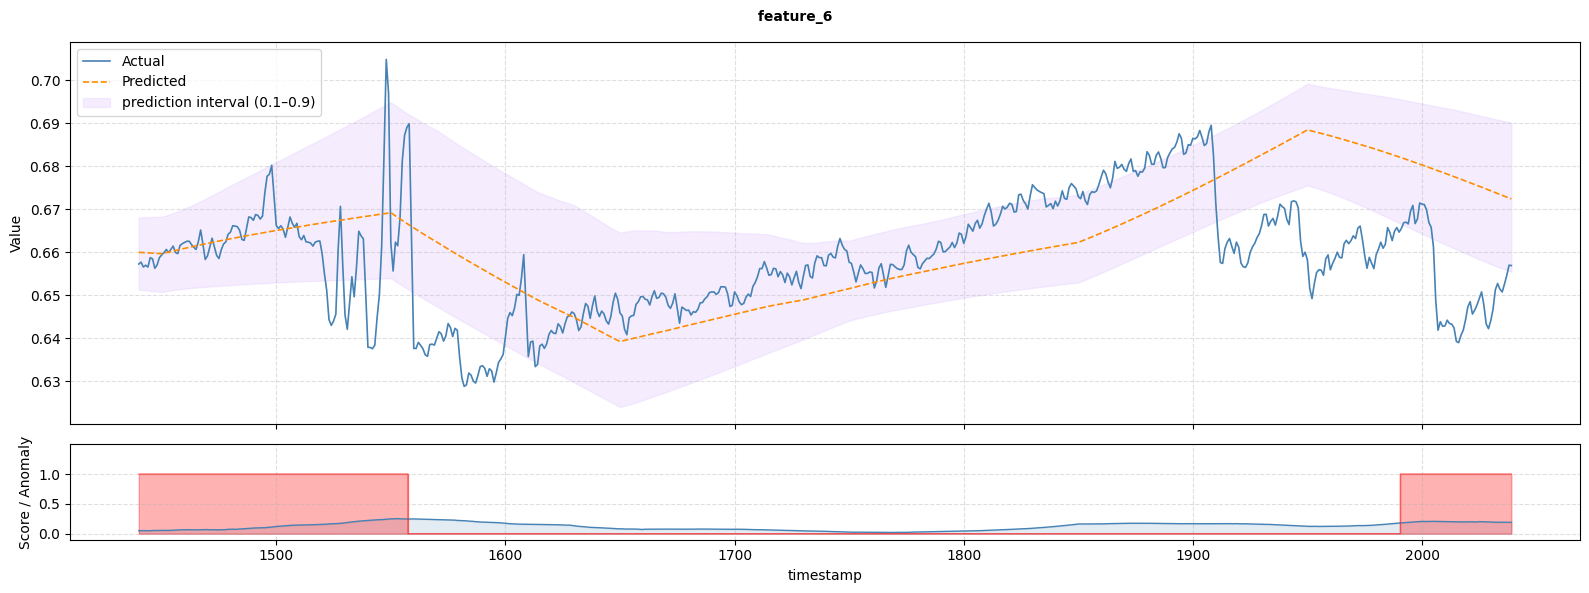

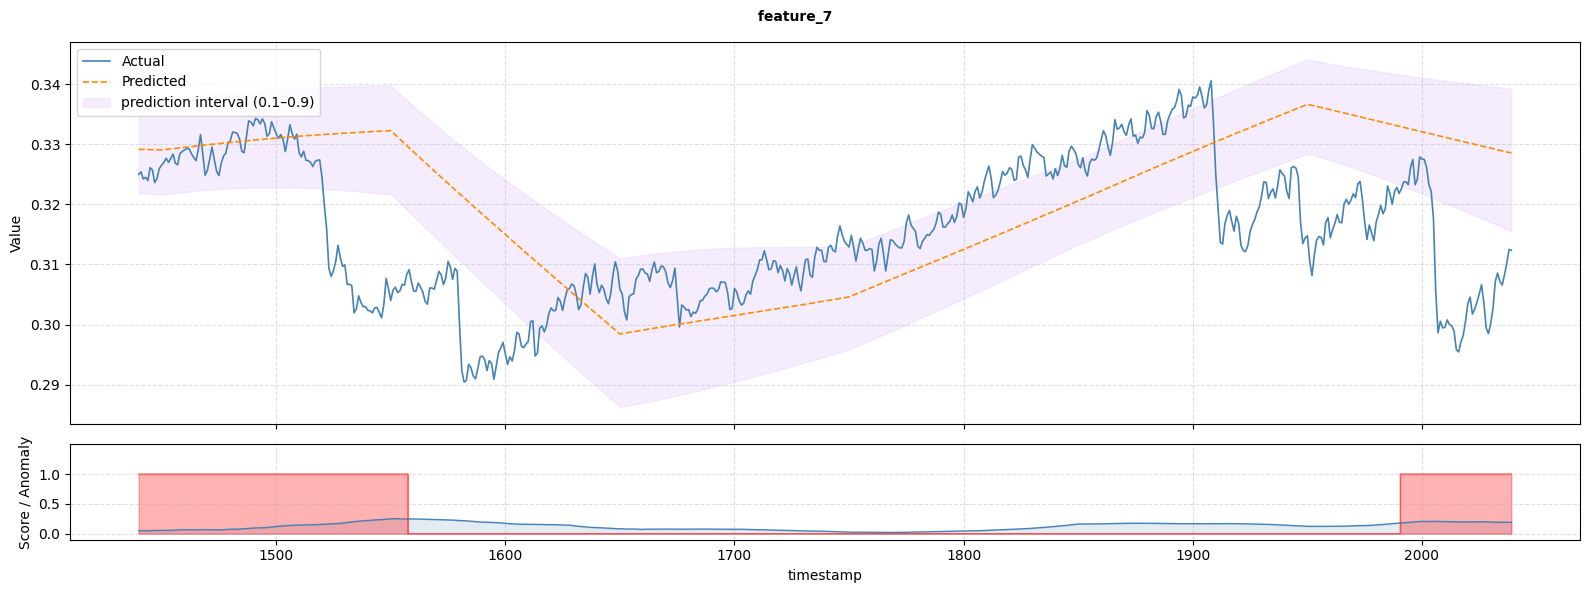

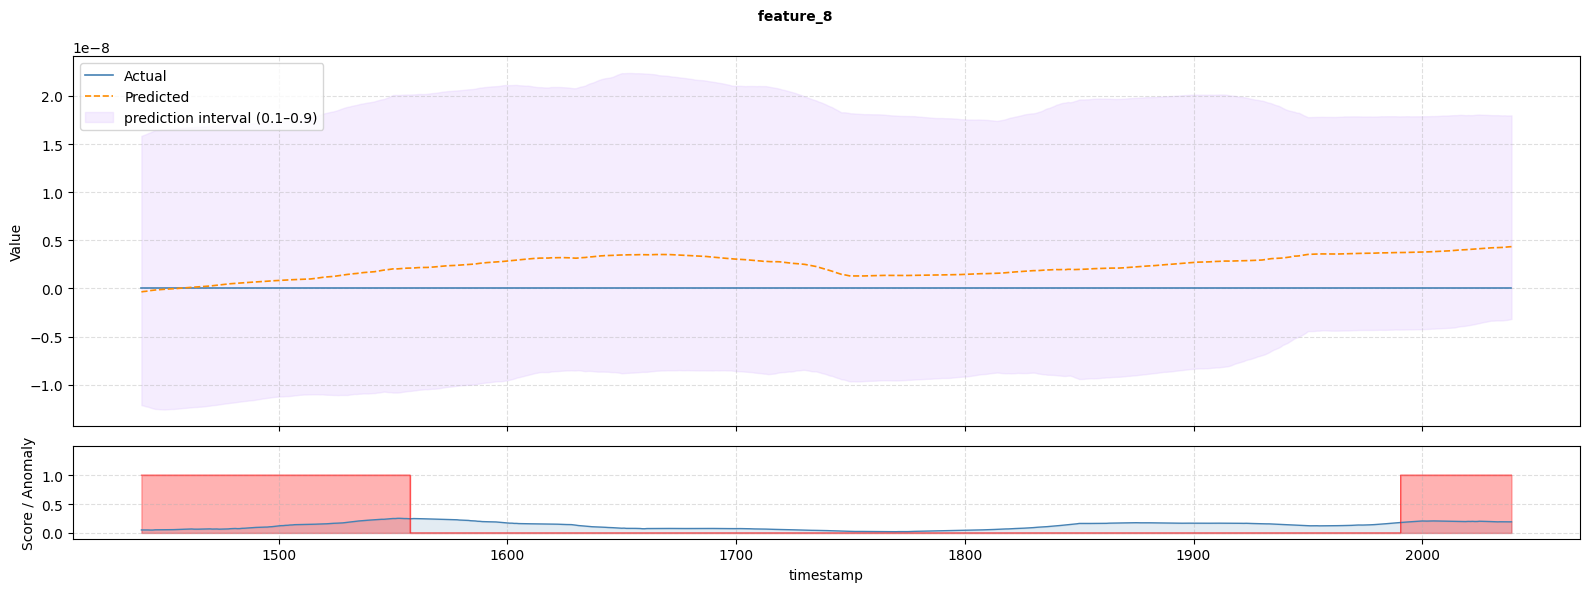

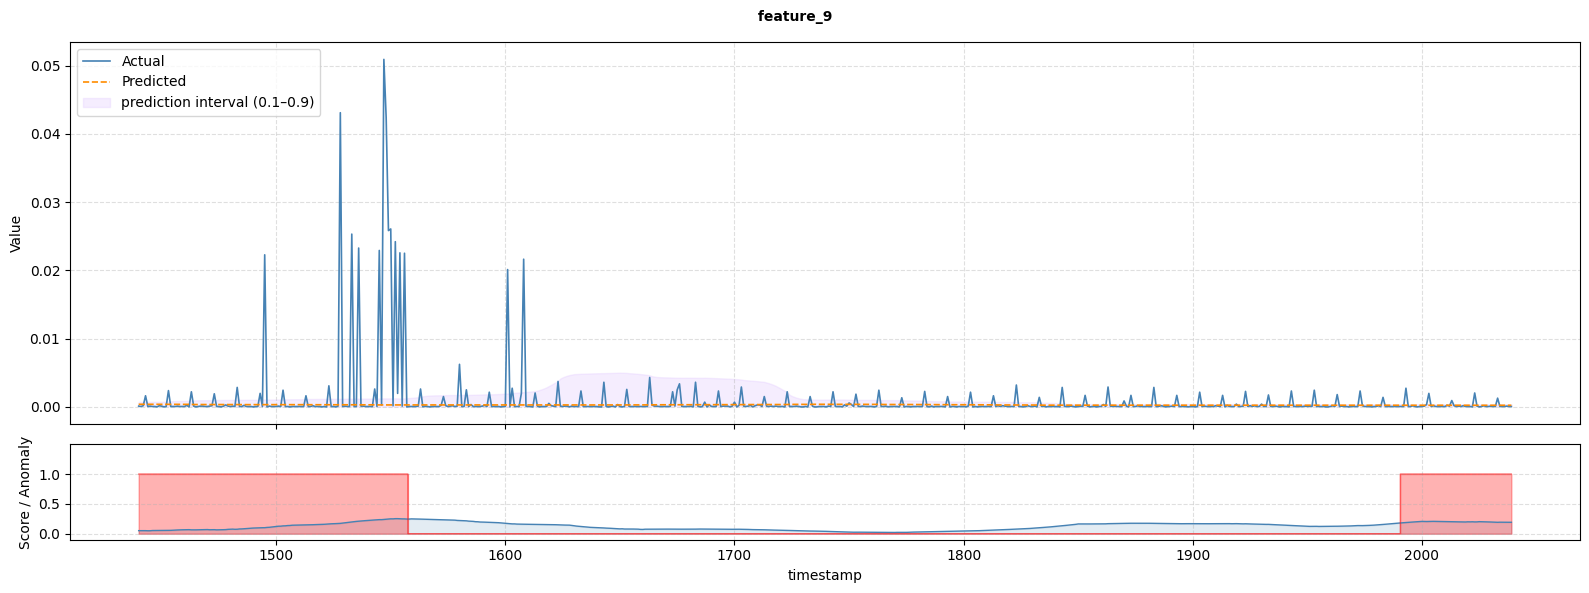

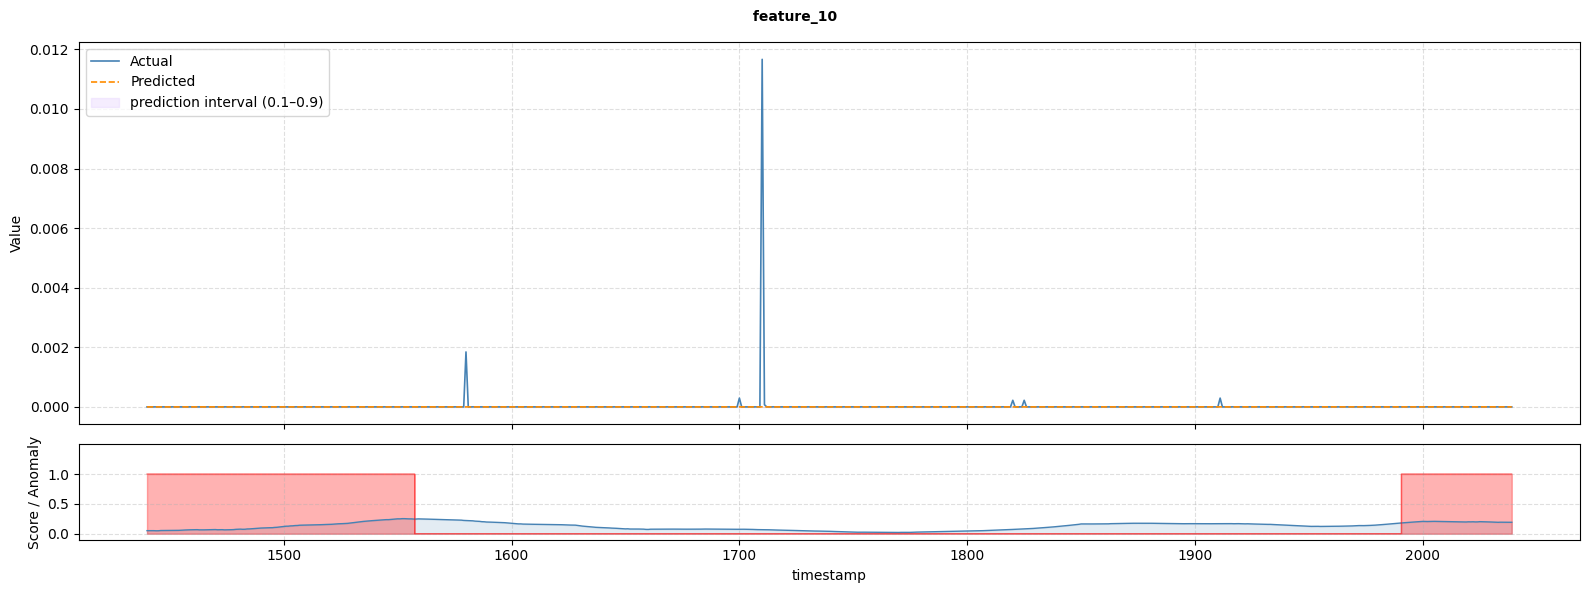

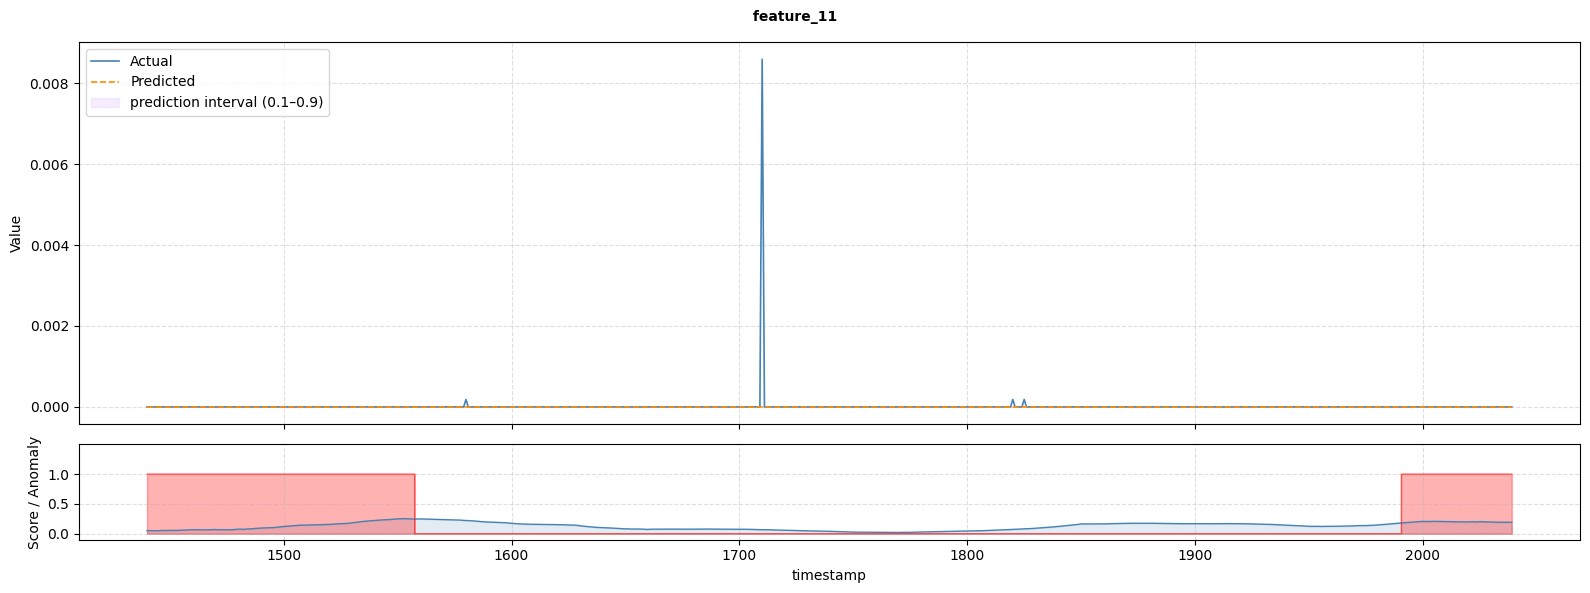

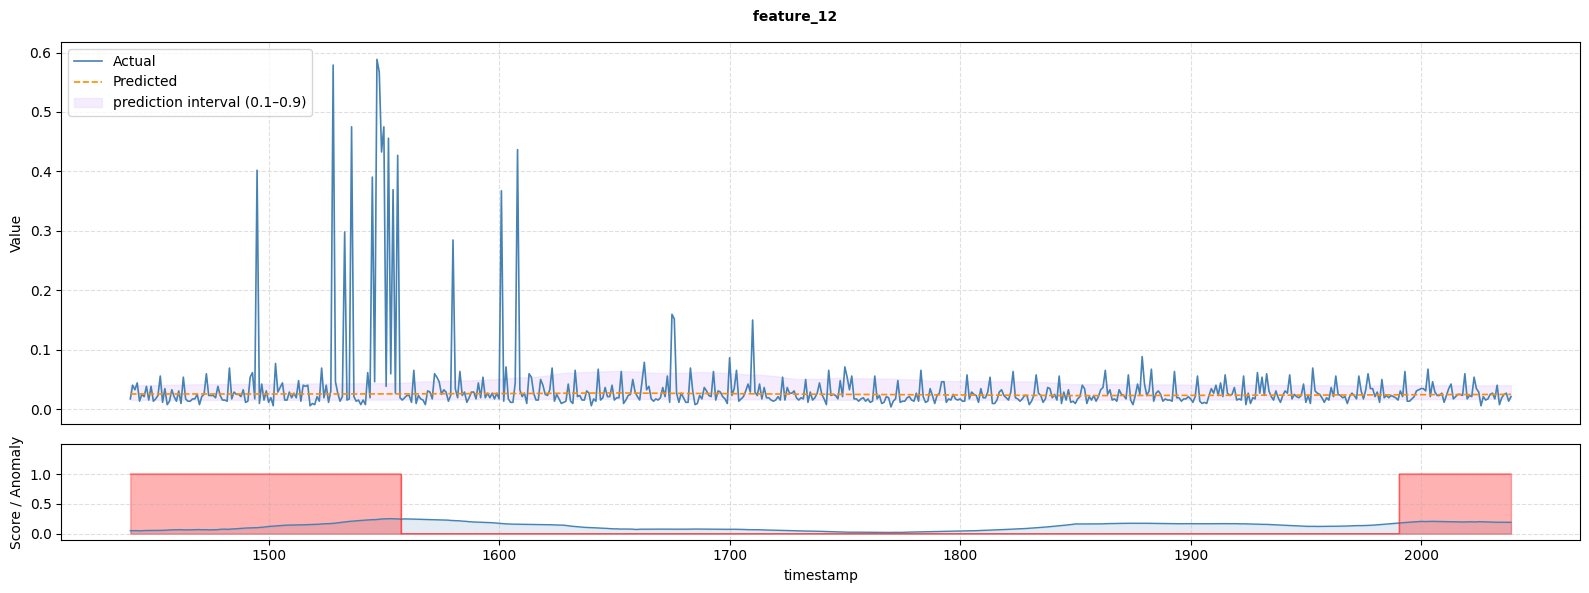

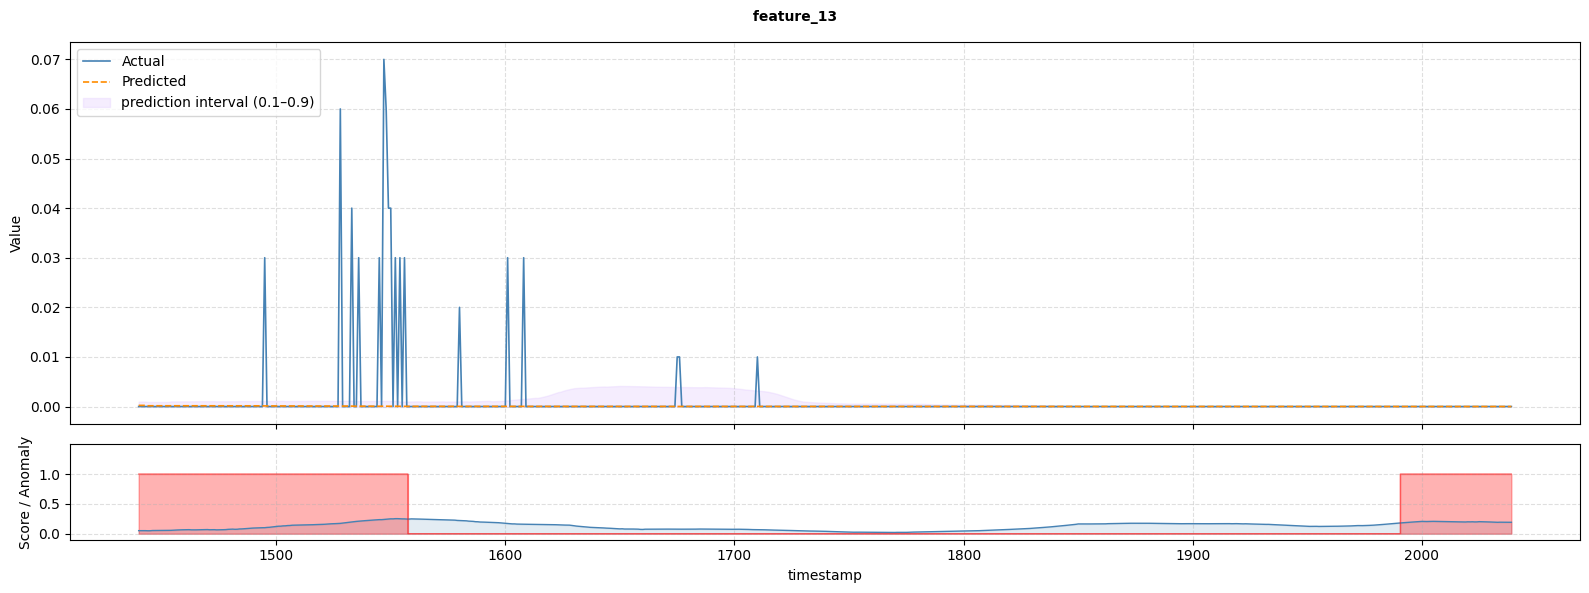

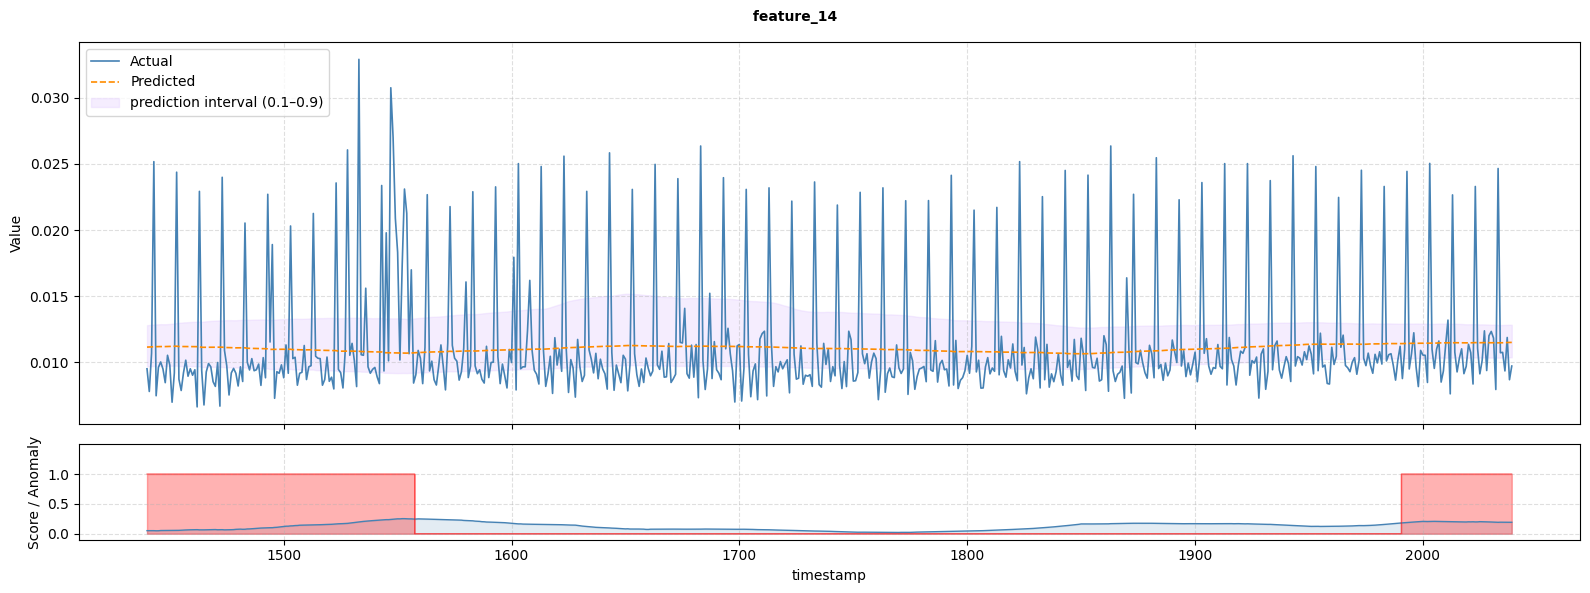

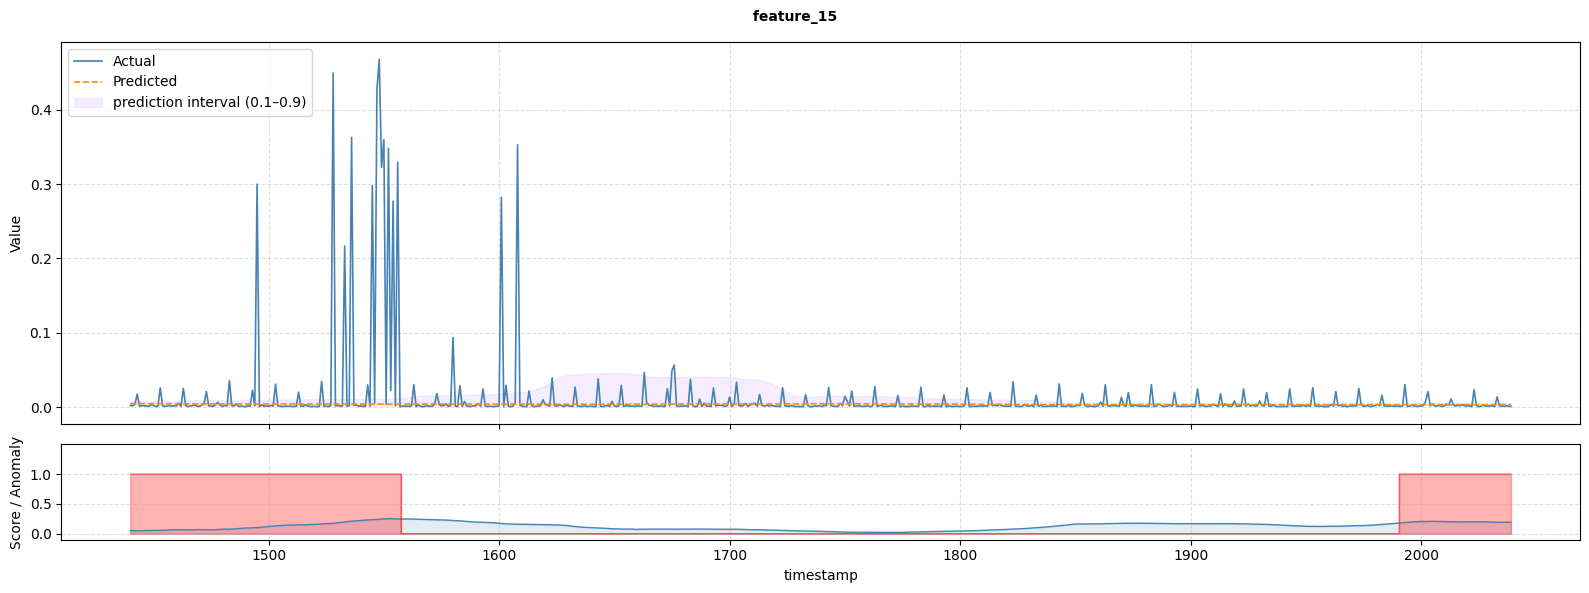

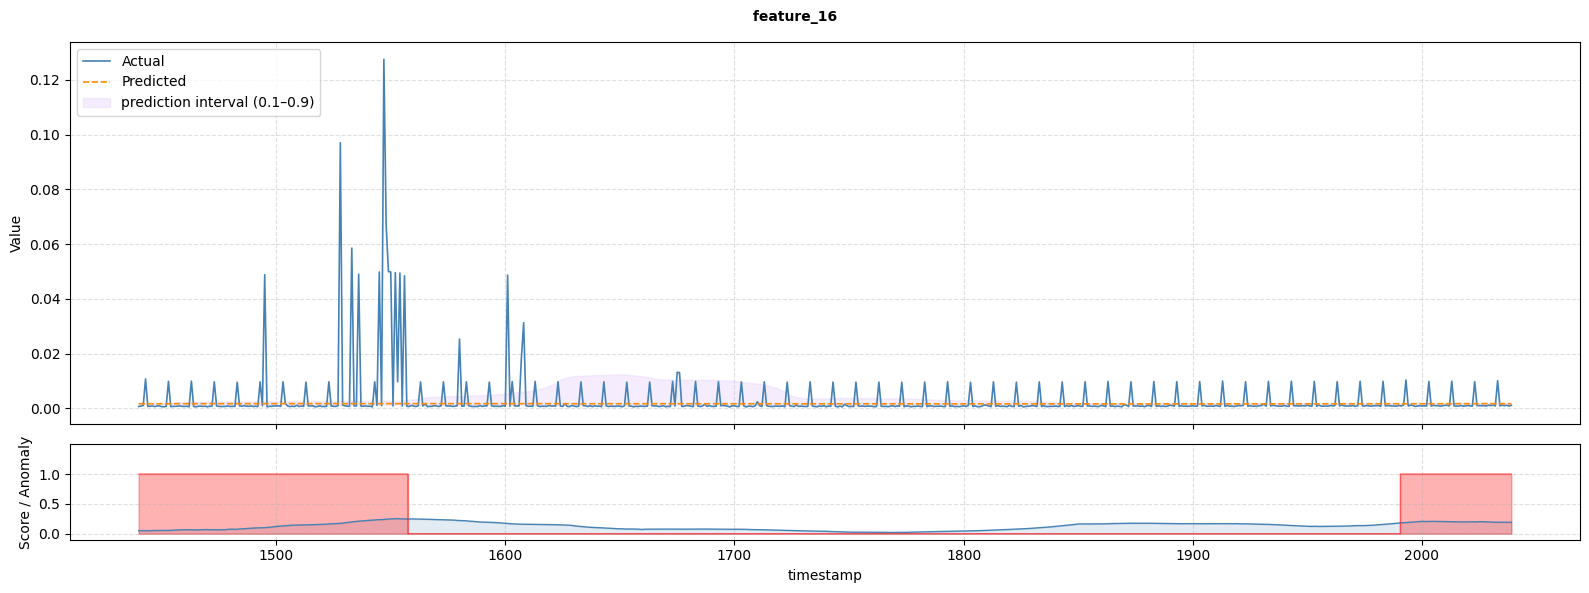

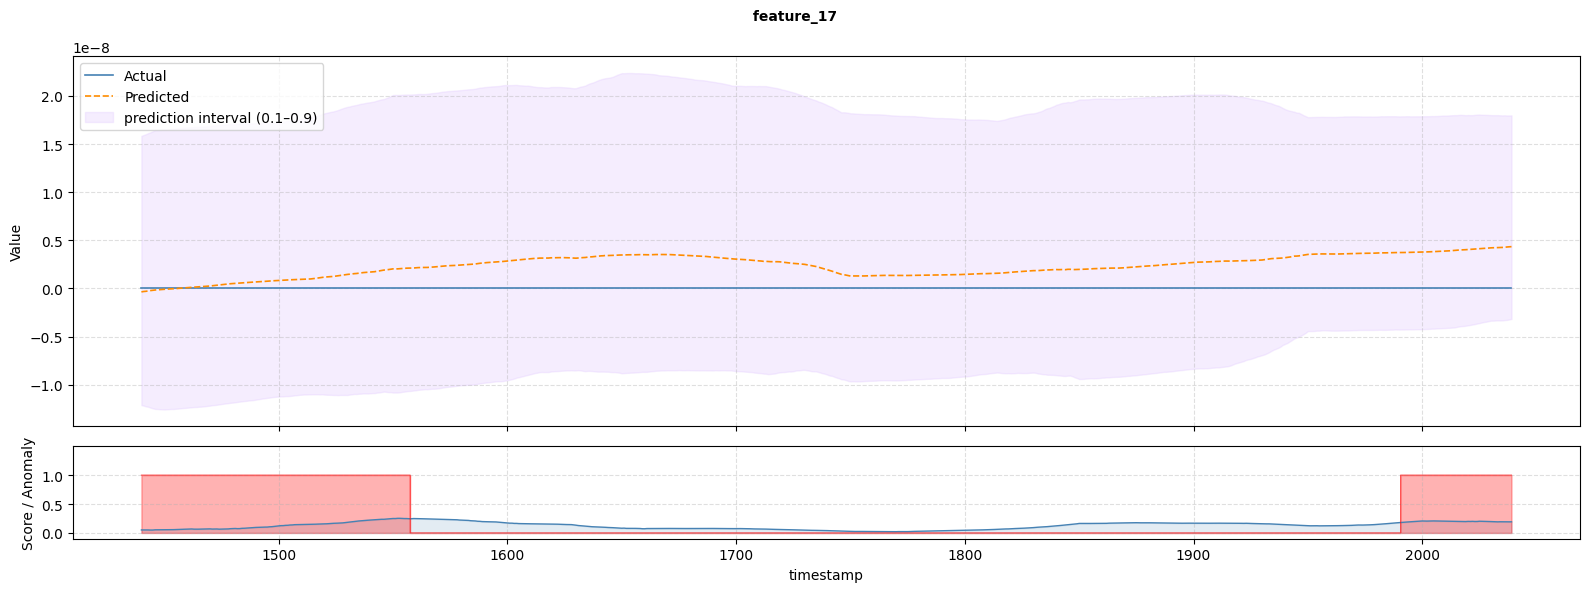

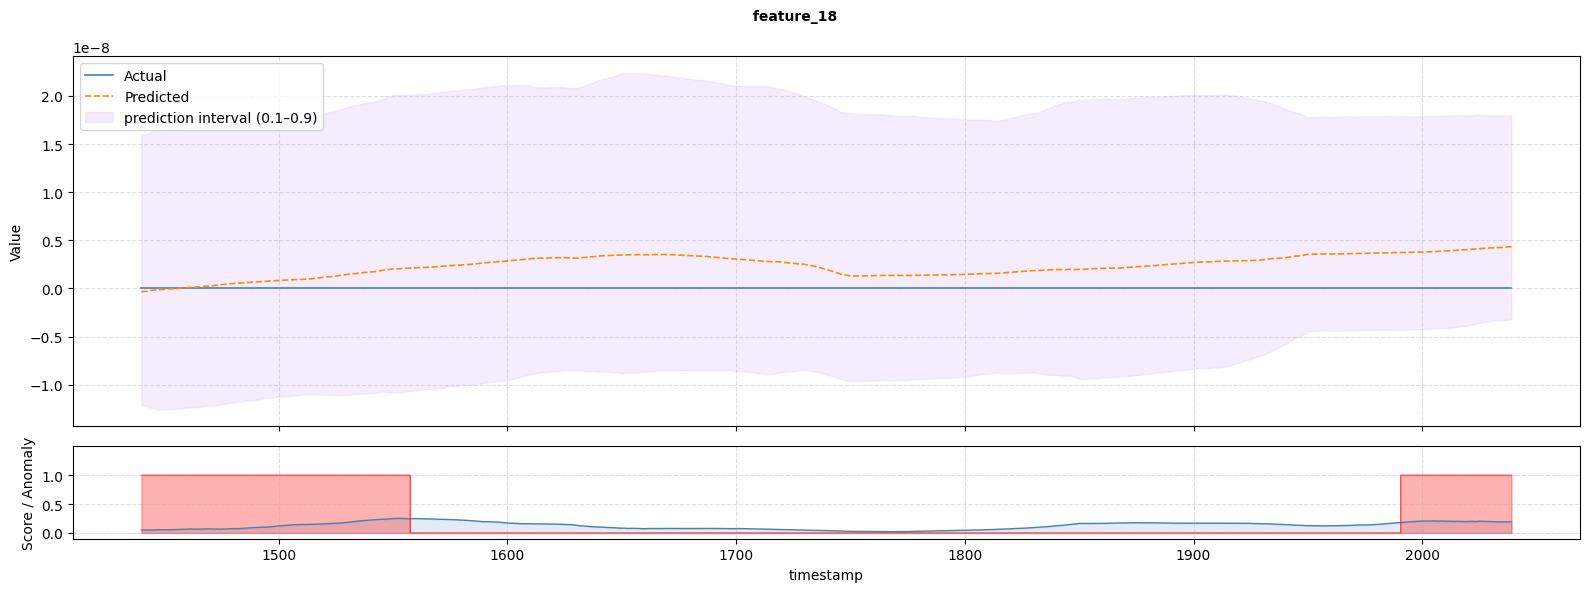

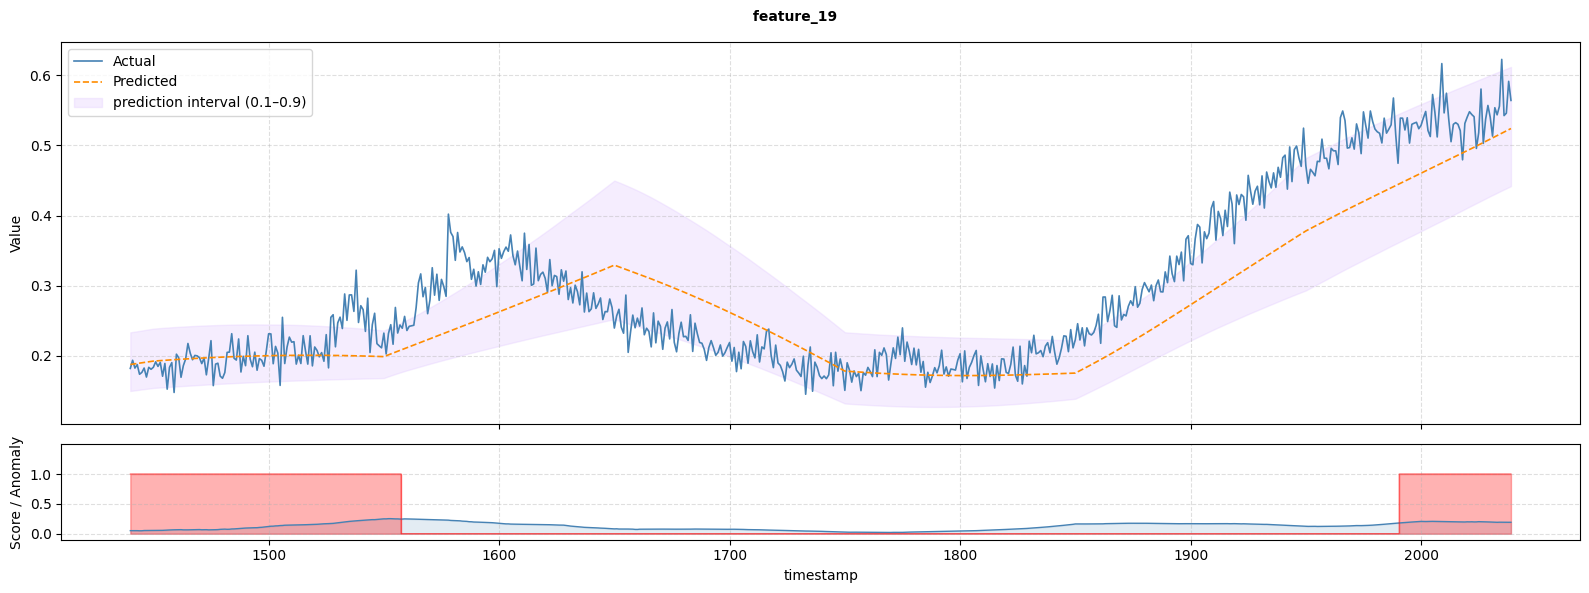

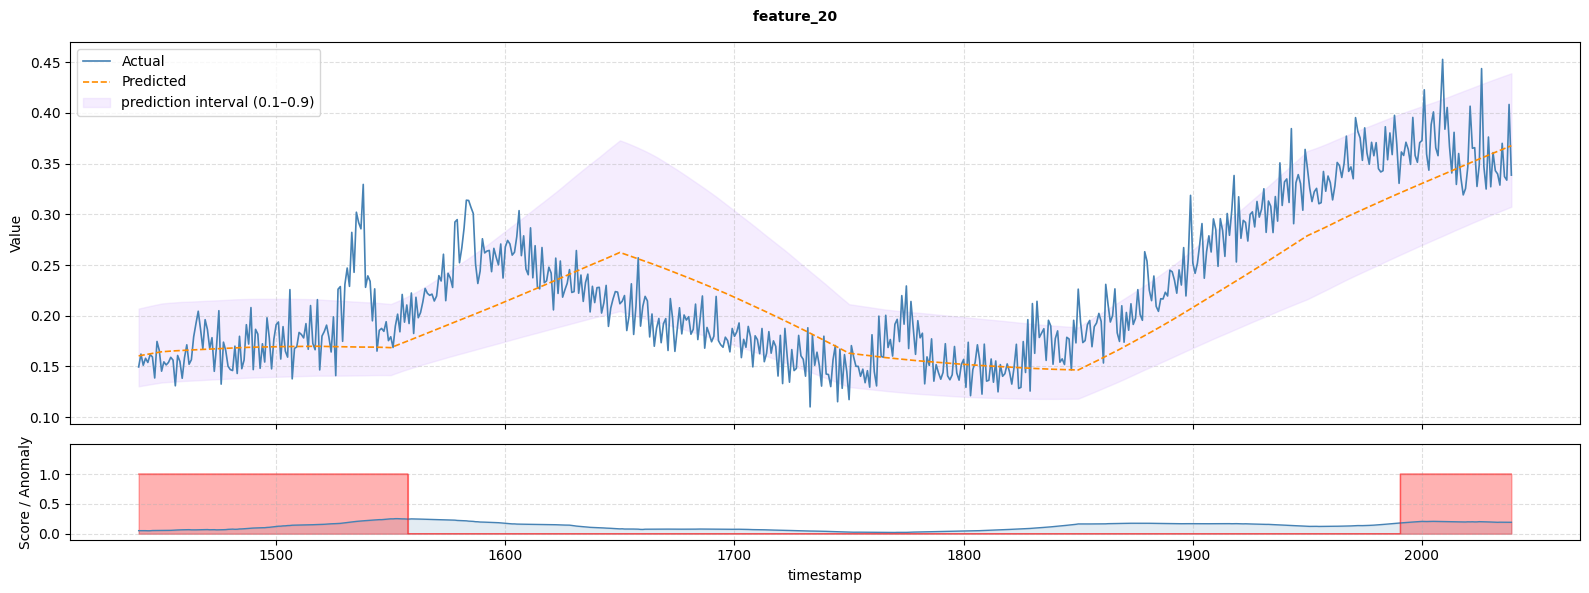

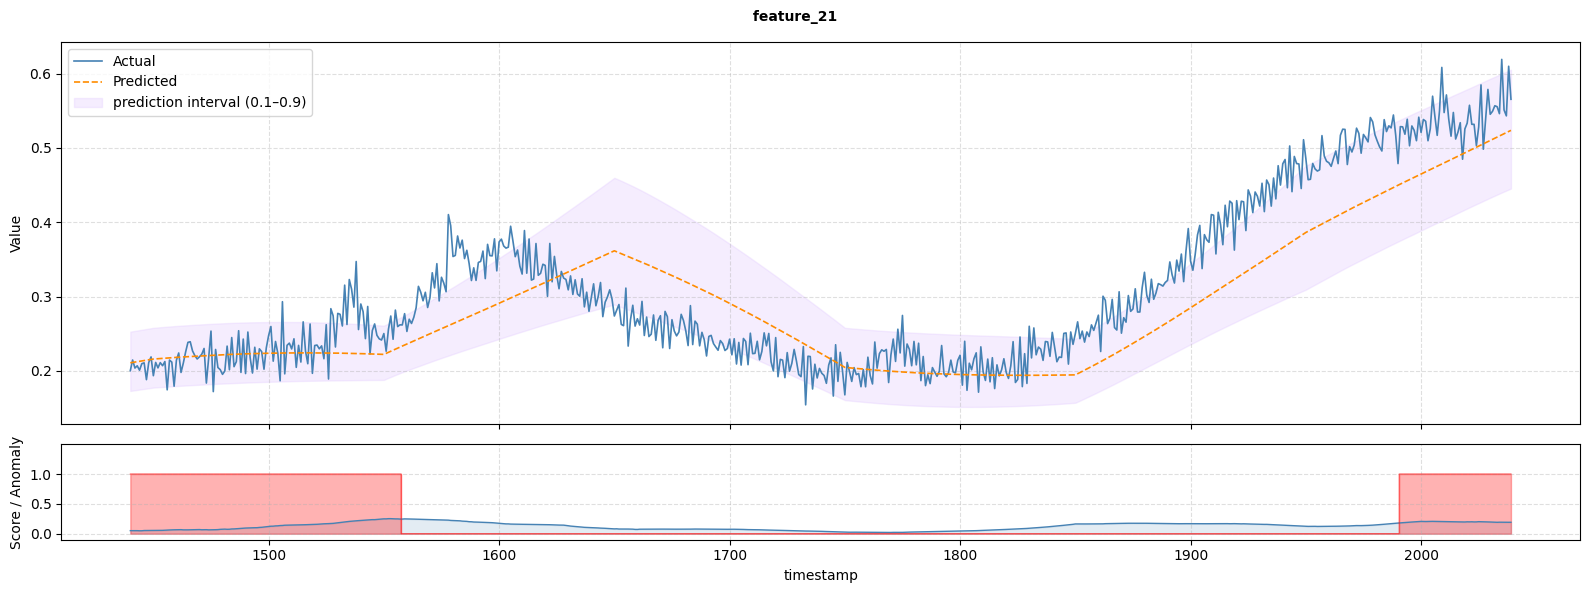

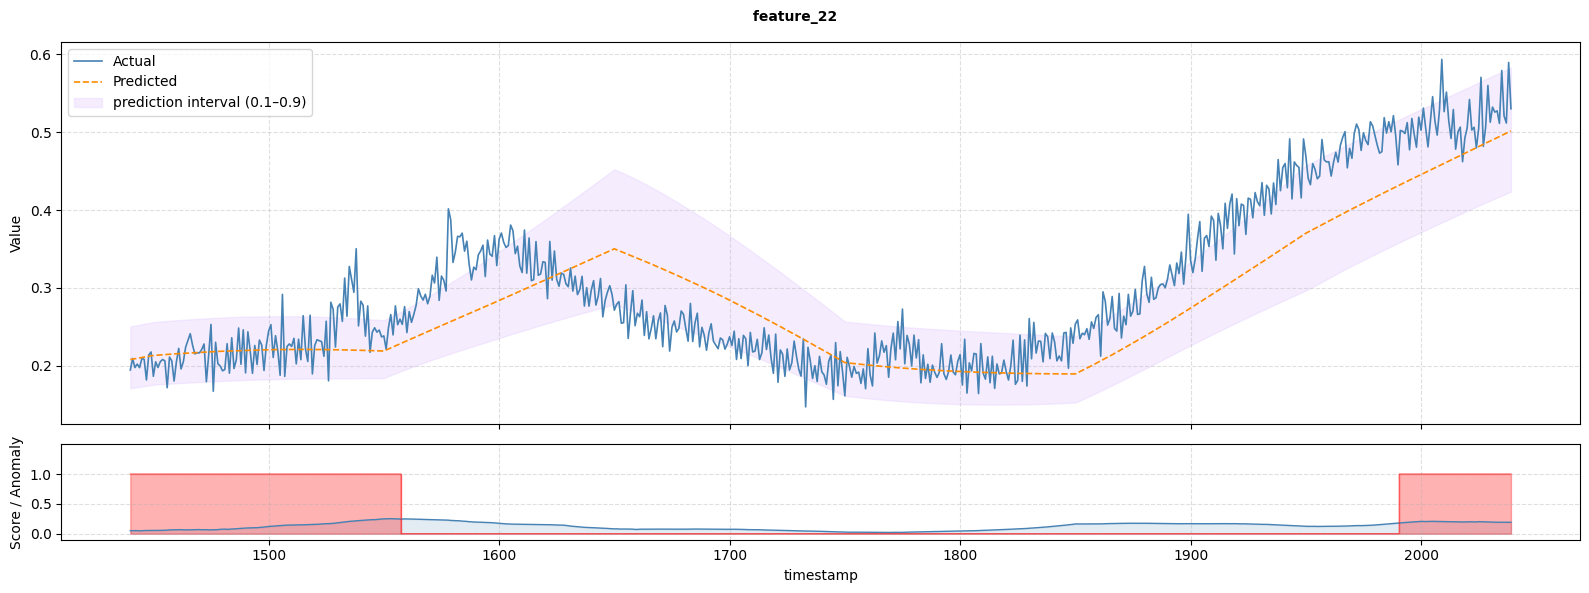

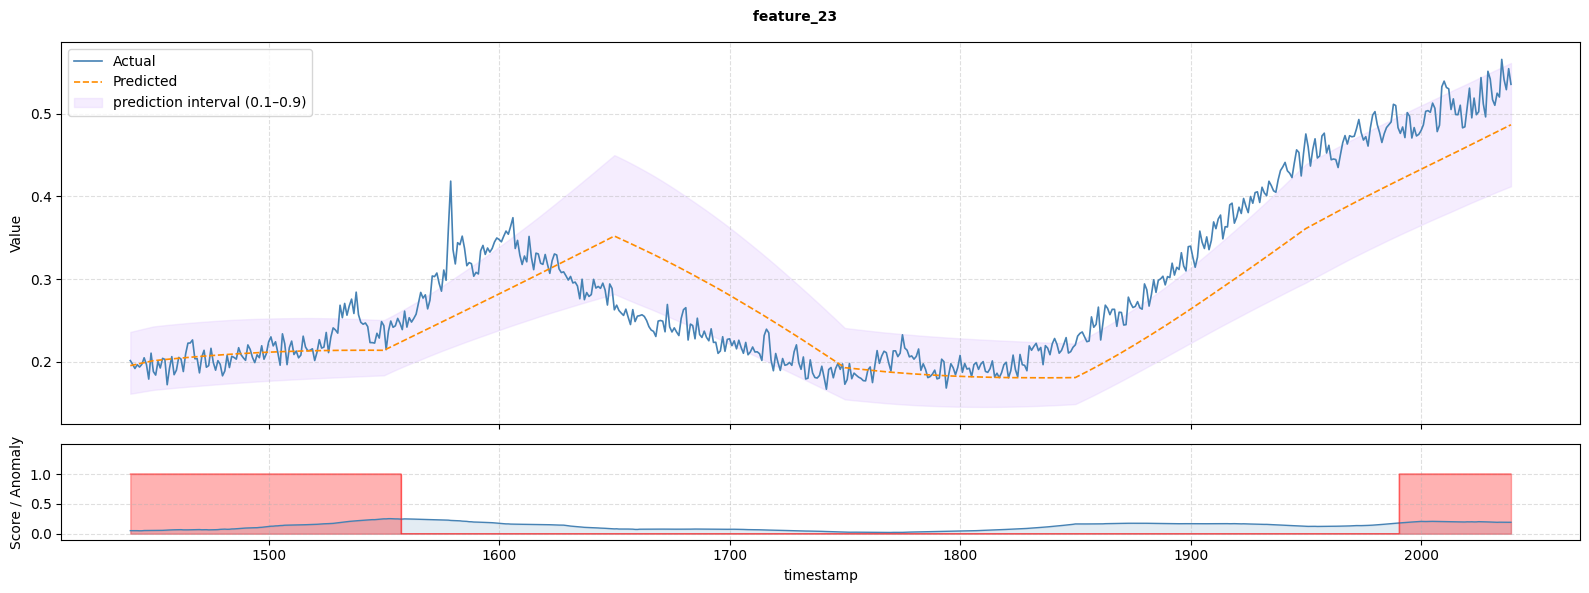

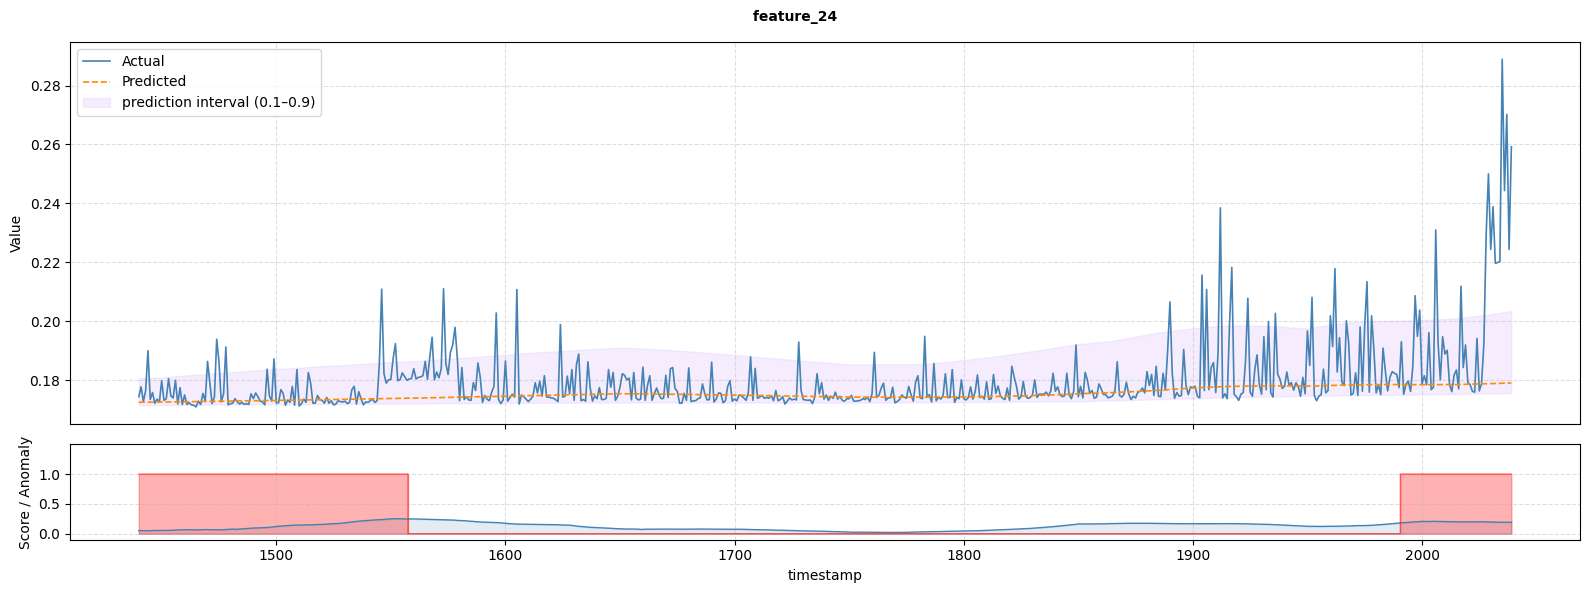

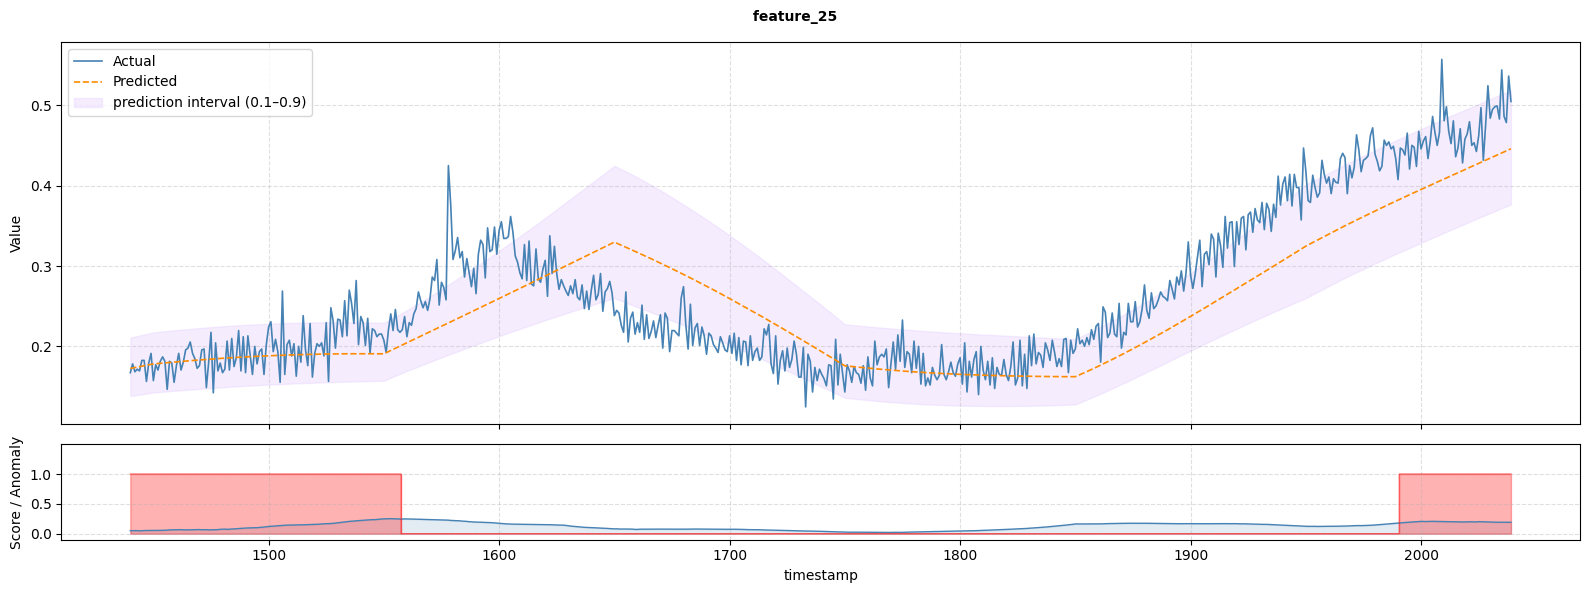

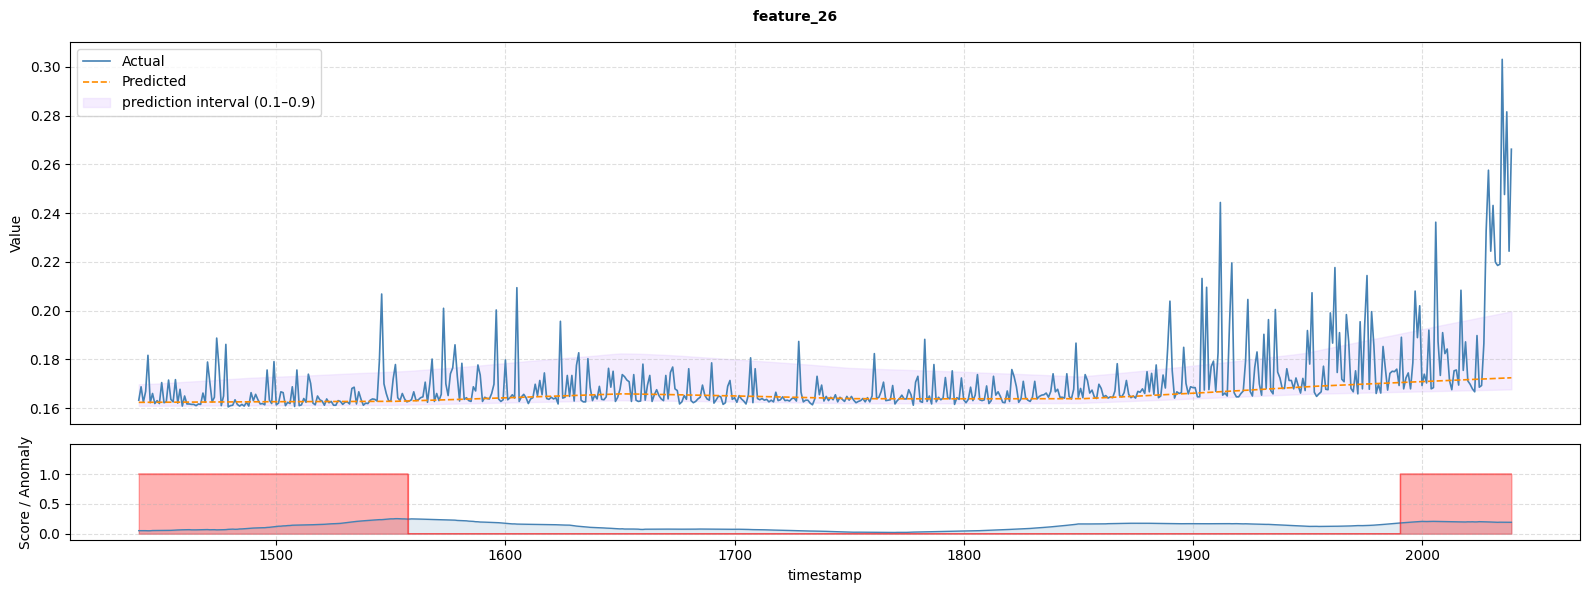

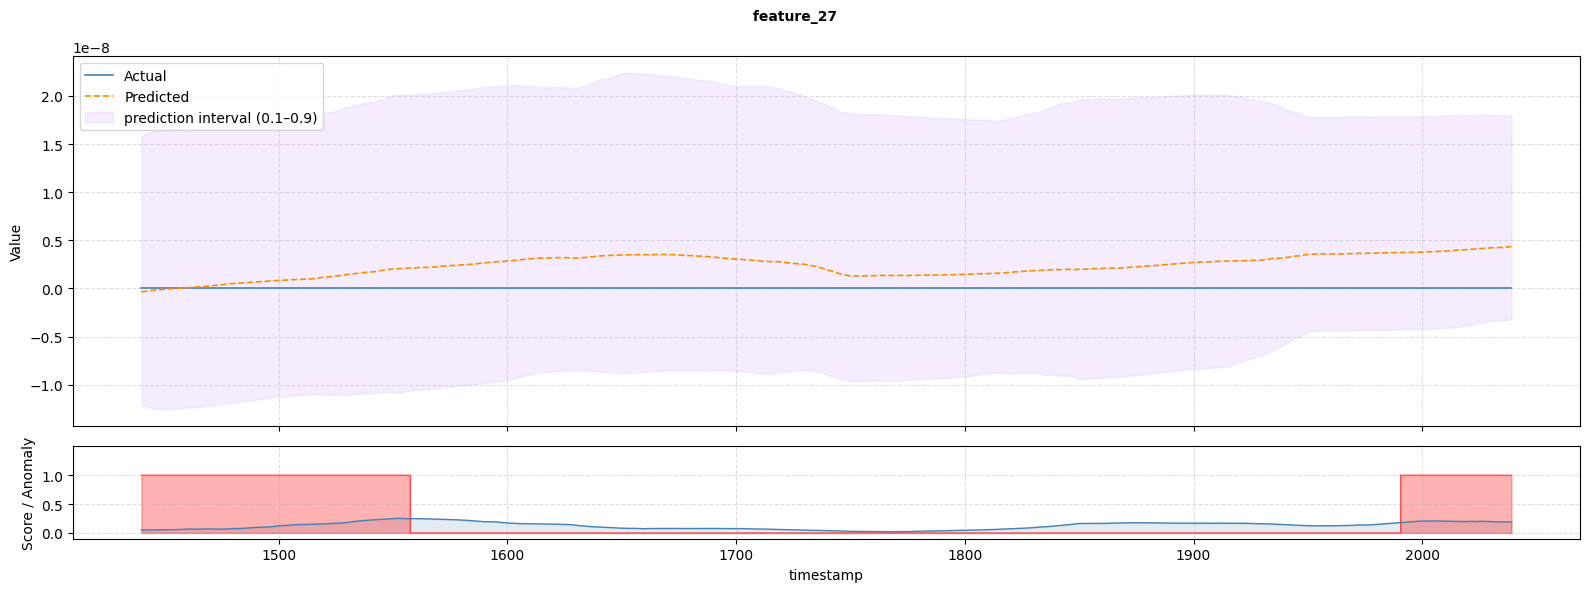

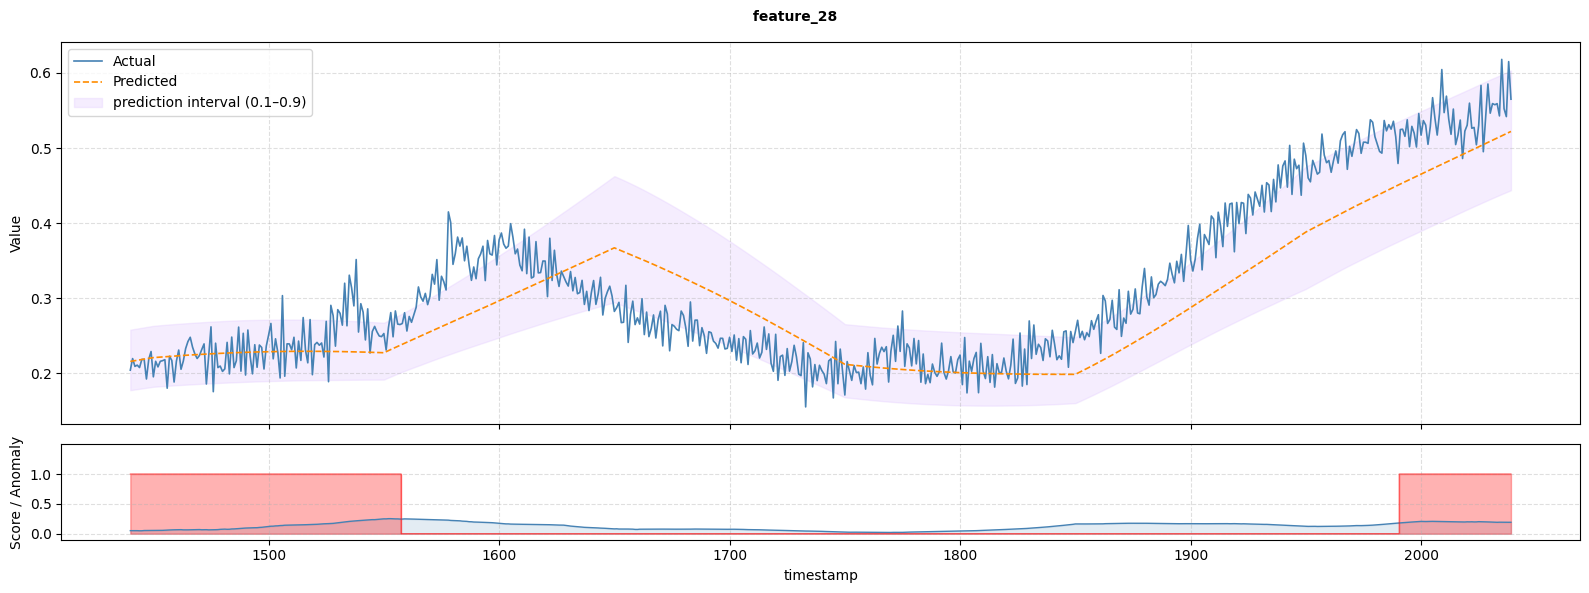

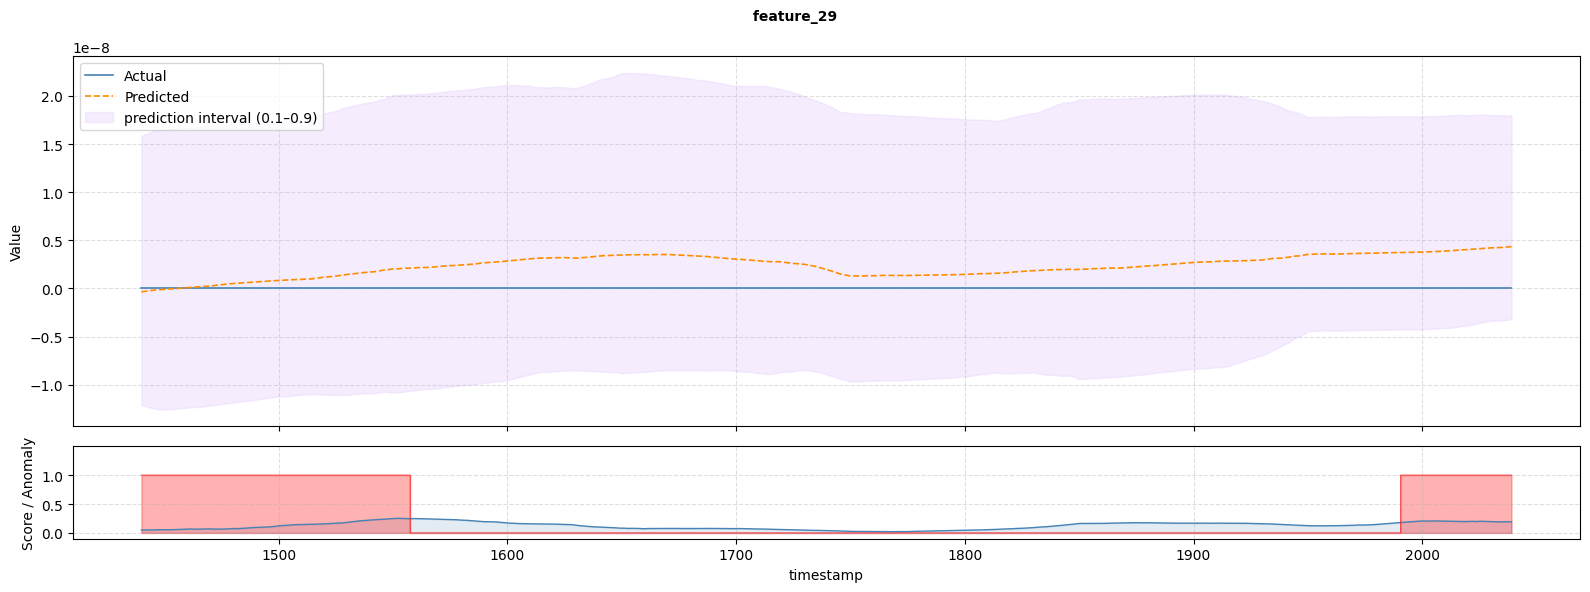

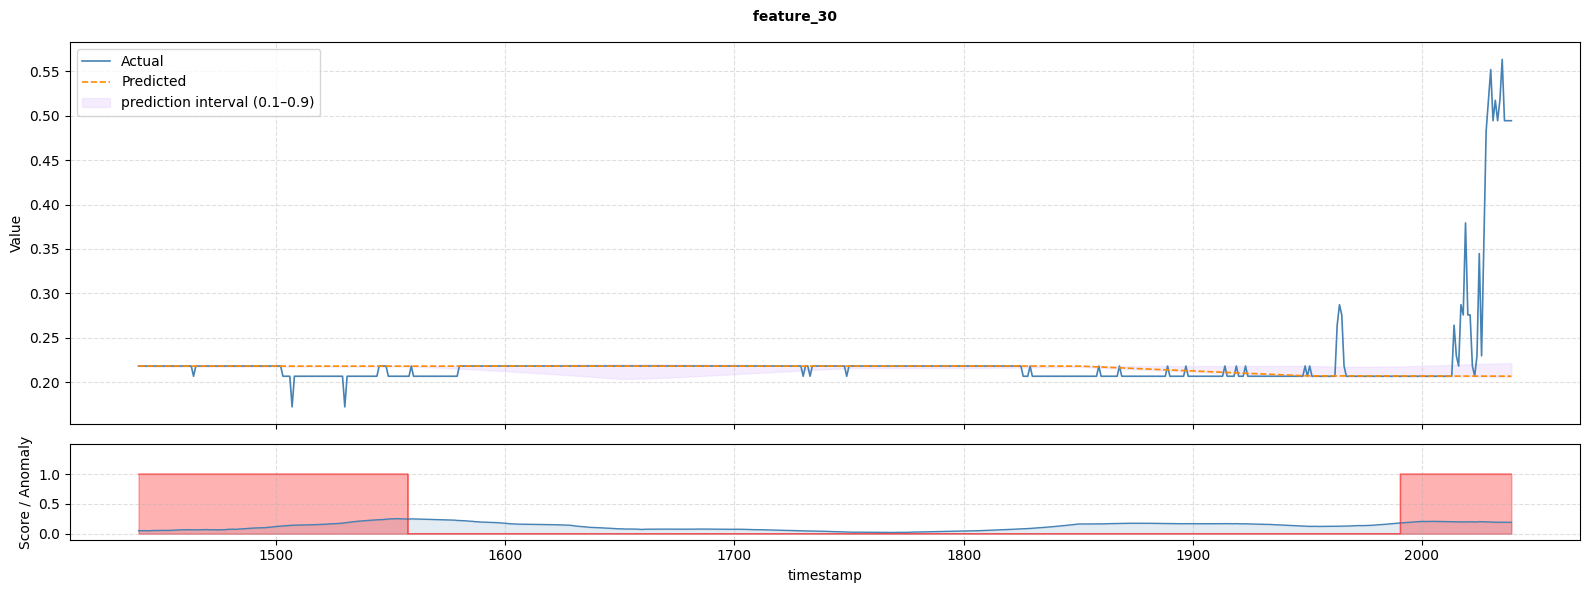

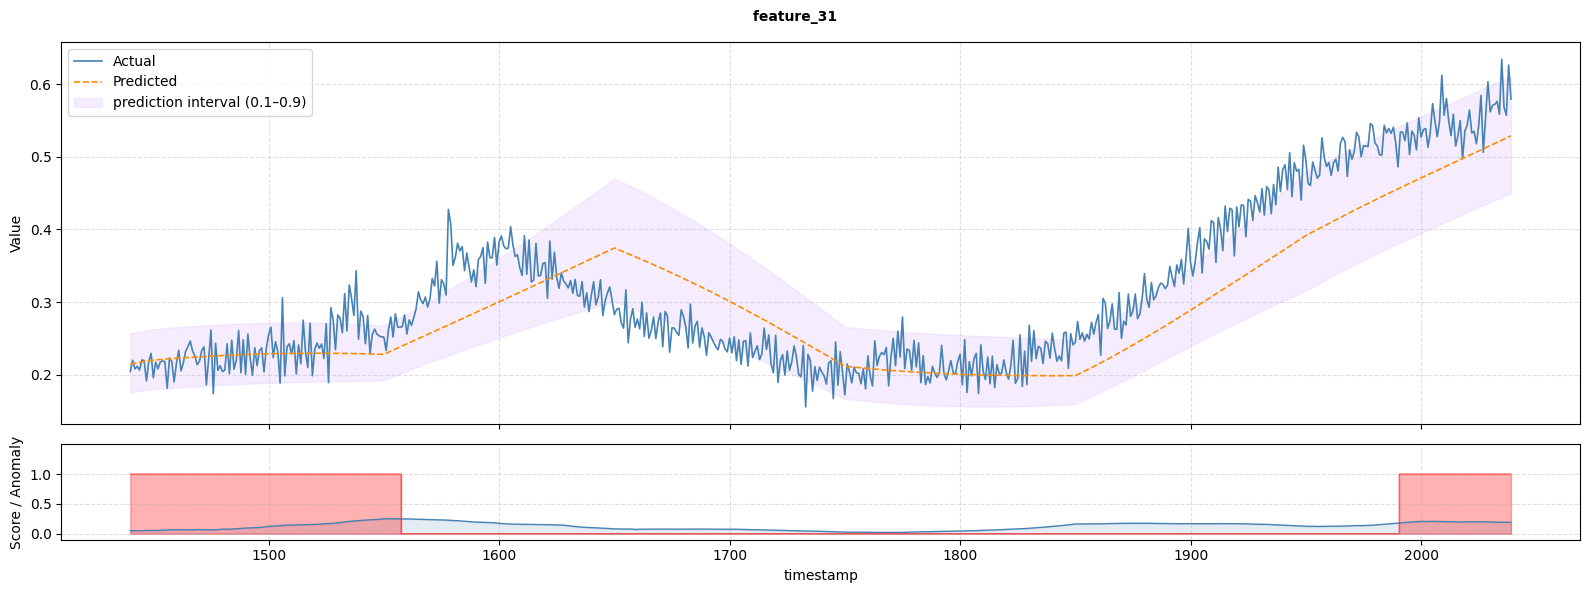

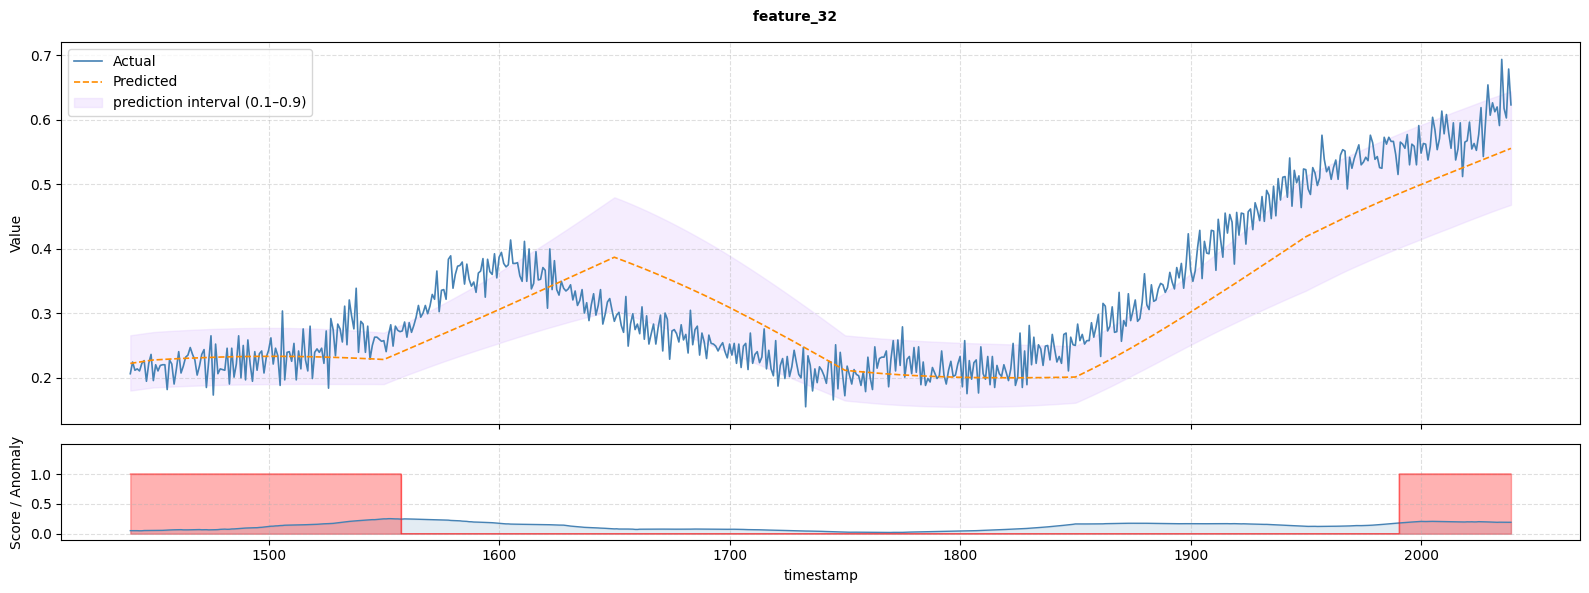

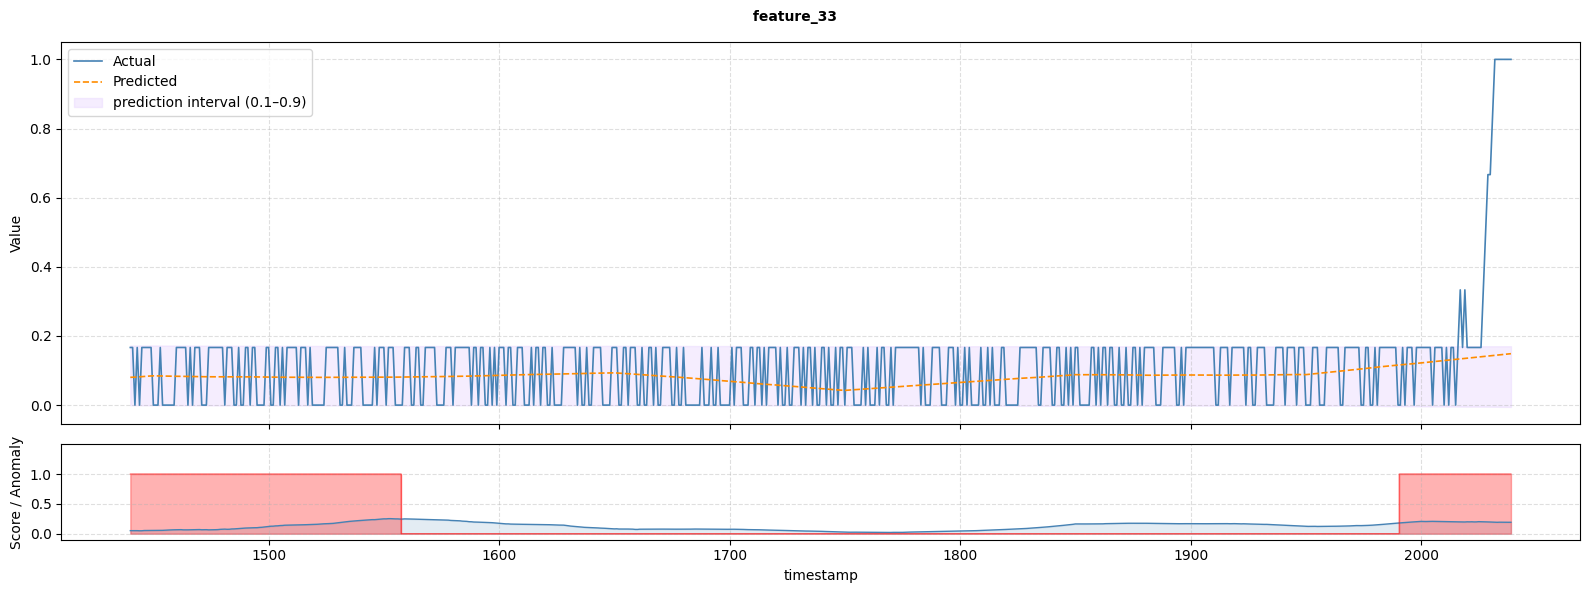

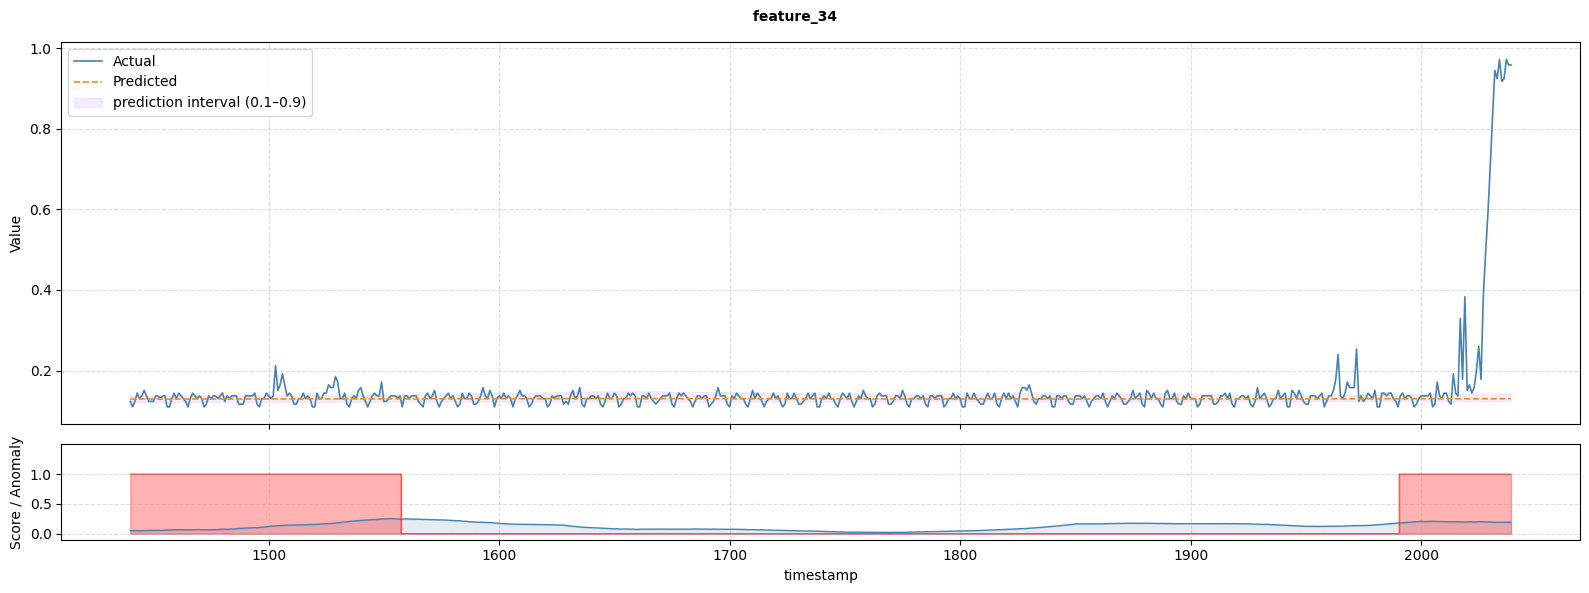

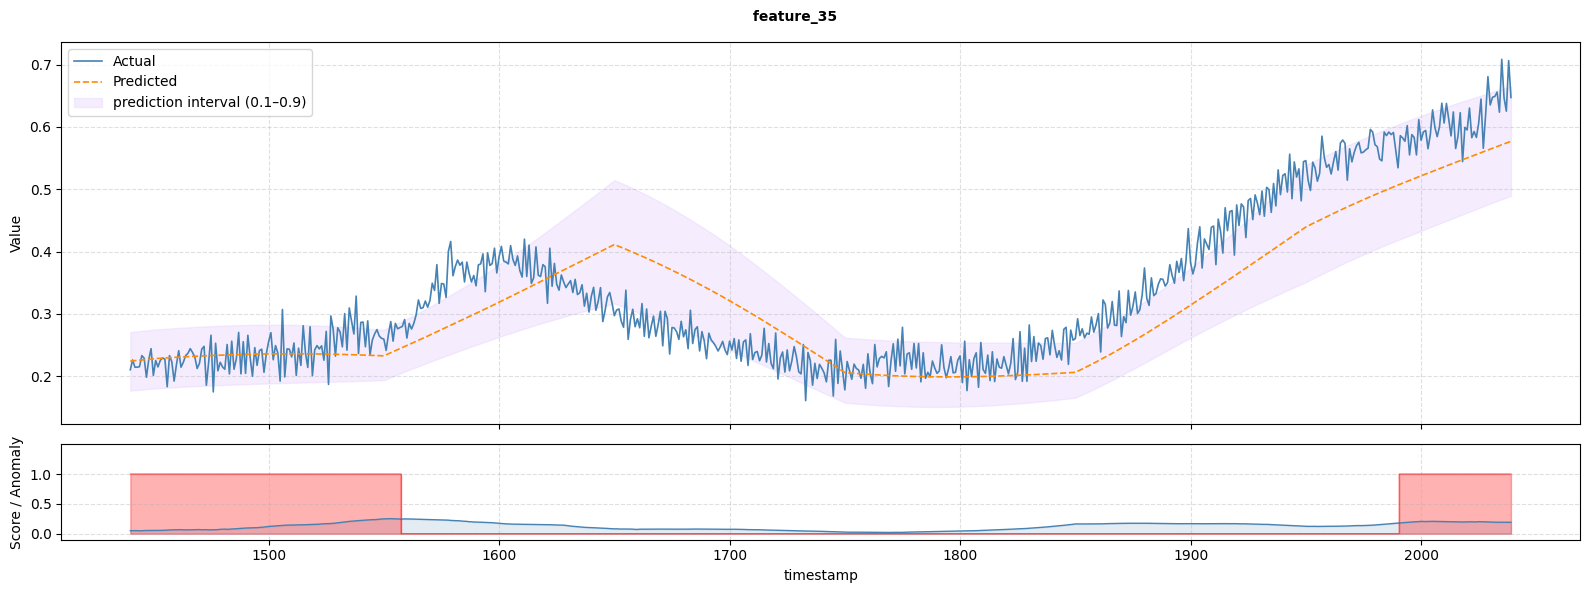

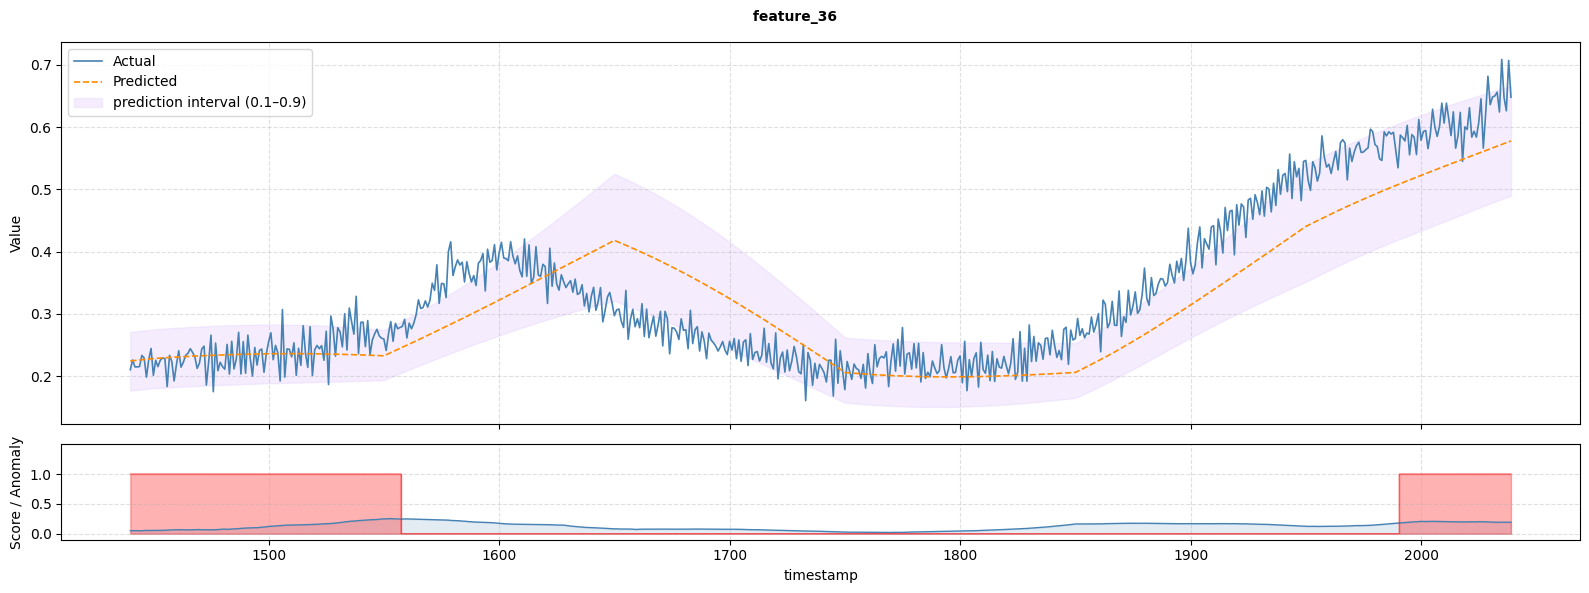

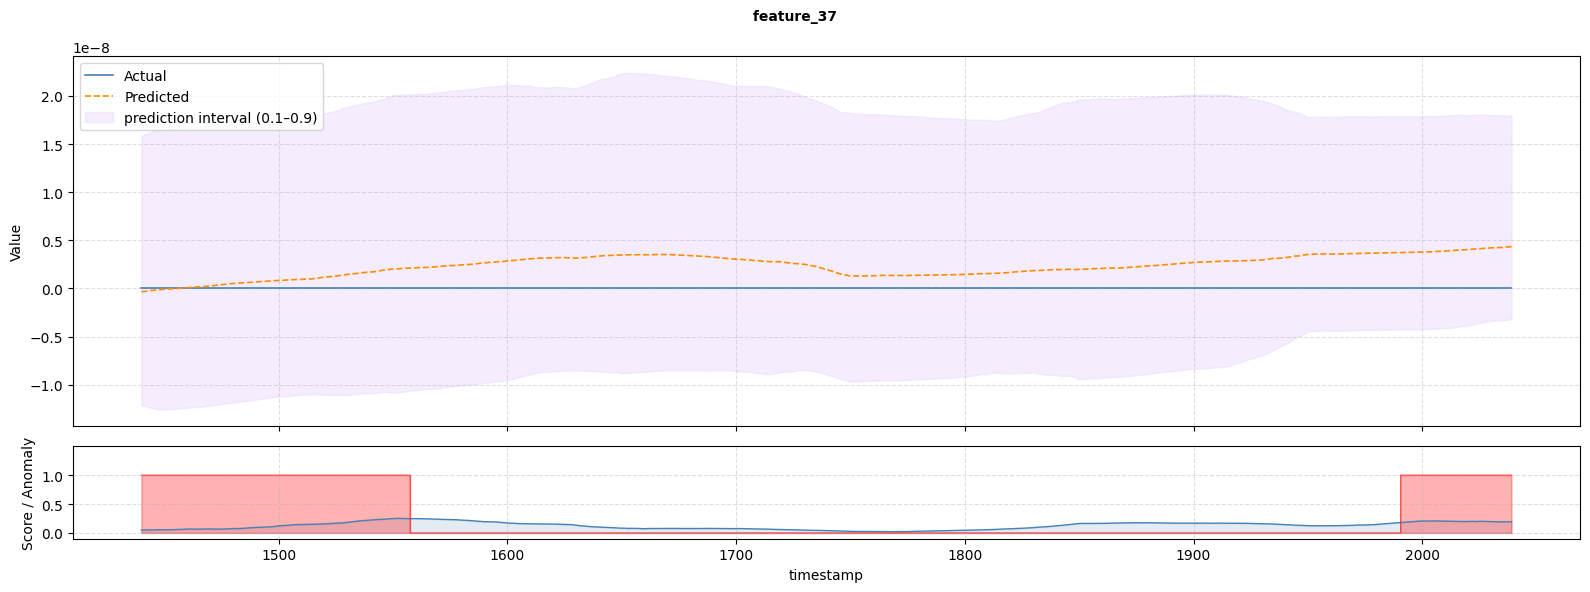

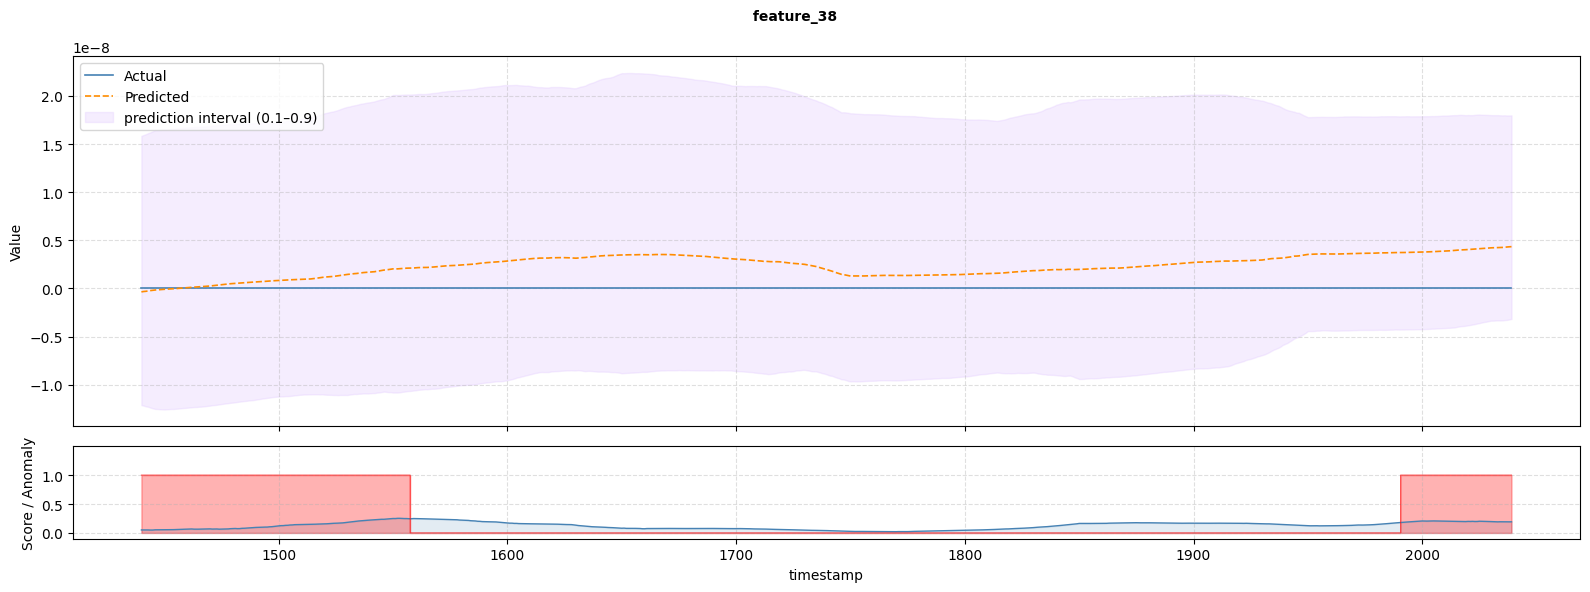

In [ ]:
for i in range(1,39):
    
    plot_forecast_with_anomaly(feature_groups, df_test, y_score, feature_idx=i, plot_from=1440, plot_until=2040)